# Importo librerías

In [18]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
import warnings
import pickle
import re
from scipy.stats import wilcoxon

# from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt

### Helper funcs

In [19]:
def sanitize_for_pickle(obj):
    if isinstance(obj, pd.DataFrame):
        obj = obj.copy()
        for col in obj.columns:
            if str(obj[col].dtype).startswith("string"):
                obj[col] = obj[col].astype(object)
        return obj

    elif isinstance(obj, pd.Series):
        if str(obj.dtype).startswith("string"):
            return obj.astype(object)
        return obj

    elif isinstance(obj, dict):
        return {k: sanitize_for_pickle(v) for k, v in obj.items()}

    elif isinstance(obj, list):
        return [sanitize_for_pickle(x) for x in obj]

    elif isinstance(obj, tuple):
        return tuple(sanitize_for_pickle(x) for x in obj)

    else:
        return obj

In [20]:
def summarize_results(all_results):
    def dataset_metadata(dataset_name):
        dataset_dir = Path("dataset") / "data_base" / dataset_name
        dat_files = sorted([p for p in dataset_dir.glob(f"{dataset_name}-{dataset_name}-cc.dat") if p.is_file()])
        if not dat_files:
            return {
                "n_instances": np.nan,
                "n_categorical_features": np.nan,
                "n_numerical_features": np.nan,
                "n_total_features": np.nan,
                "pct_numerical_features": np.nan,
                "pct_categorical_features": np.nan,
                "n_classes": np.nan,
            }

        file_path = dat_files[0]
        n_instances = np.nan
        in_data = False

        n_categorical_features = 0
        n_numerical_features = 0
        last_attribute_categories = None

        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            for raw_line in f:
                line = raw_line.strip()
                if not line or line.startswith("%"):
                    continue

                lower = line.lower()
                if lower.startswith("@attribute"):
                    if "{" in lower and "}" in lower:
                        n_categorical_features += 1
                        last_attribute_categories = line[line.find("{") + 1: line.rfind("}")].split(",")
                    else:
                        n_numerical_features += 1
                elif lower.startswith("@data"):
                    in_data = True
                elif in_data:
                    n_instances = 0 if pd.isna(n_instances) else n_instances
                    n_instances += 1

        n_categorical_features_no_class = n_categorical_features - 1
        n_total_features = n_numerical_features + n_categorical_features_no_class

        return {
            "n_instances": n_instances,
            "n_categorical_features": n_categorical_features_no_class,
            "n_numerical_features": n_numerical_features,
            "n_total_features": n_total_features,
            "pct_numerical_features": (100 * n_numerical_features / n_total_features) if n_total_features else np.nan,
            "pct_categorical_features": (100 * n_categorical_features_no_class / n_total_features) if n_total_features else np.nan,
            "n_classes": len(last_attribute_categories) if last_attribute_categories is not None else np.nan,
        }

    rows = []
    for res in all_results:
        dataset = res["dataset"]
        dataset_info = dataset_metadata(dataset)
        baseline_acc_col = "acc" if "acc" in res["baseline_df"].columns else "accuracy"
        baseline_metric_cols = [baseline_acc_col, "bal_acc", "f1_macro", "precision_macro", "recall_macro"]
        if "elapsed_s" in res["baseline_df"].columns:
            baseline_metric_cols.append("elapsed_s")
        baseline_mean = (
            res["baseline_df"][baseline_metric_cols]
            .mean()
            .add_prefix("baseline_")
            .rename(index={f"baseline_{baseline_acc_col}": "baseline_acc"})
        )
        class_df = res["class_summary_df"].copy()
        if "class_acc_mean" not in class_df.columns:
            if "accuracy_mean" in class_df.columns:
                class_df["class_acc_mean"] = class_df["accuracy_mean"]
            elif "acc_mean" in class_df.columns:
                class_df["class_acc_mean"] = class_df["acc_mean"]
        class_df["method_base"] = class_df["method"].str.split("_", n=1).str[0]
        best_class = (
            class_df.sort_values(
                by=["method_base", "f1_macro_mean", "bal_acc_mean", "class_acc_mean", "precision_macro_mean", "recall_macro_mean"],
                ascending=[True, False, False, False, False, False],
            )
            .groupby("method_base", as_index=False)
            .head(1)
        )
        removal_df = res["removal_summary_df"].copy()
        removal_df["method_base"] = removal_df["filter"].str.split("_", n=1).str[0]
        best_removal = (
            removal_df.merge(
                best_class[["dataset", "noise_type", "noise_pct", "seed", "k", "method", "method_base"]],
                left_on=["dataset", "noise_type", "noise_pct", "seed", "k", "method_base"],
                right_on=["dataset", "noise_type", "noise_pct", "seed", "k", "method_base"],
                how="inner",
                suffixes=("", "_bestclass"),
            )
        )
        for _, c_row in best_class.iterrows():
            m = c_row["method_base"]
            class_rows = res["classification_df"][res["classification_df"]["method"] == c_row["method"]]
            n_invalid_trainings = int(not class_rows["valid_classification"].all()) if not class_rows.empty else np.nan
            r_row = best_removal[best_removal["method_base"] == m].iloc[0] if not best_removal[best_removal["method_base"] == m].empty else None
            row = {
                "dataset": dataset,
                **dataset_info,
                "method_base": m,
                "n_invalid_trainings": n_invalid_trainings,
                "acc_diff": c_row["class_acc_mean"] - baseline_mean["baseline_acc"],
                "bal_acc_diff": c_row["bal_acc_mean"] - baseline_mean["baseline_bal_acc"],
                "f1_macro_diff": c_row["f1_macro_mean"] - baseline_mean["baseline_f1_macro"],
                "prec_macro_diff": c_row["precision_macro_mean"] - baseline_mean["baseline_precision_macro"],
                "rec_macro_diff": c_row["recall_macro_mean"] - baseline_mean["baseline_recall_macro"],
                "removal_filter": r_row["filter"] if r_row is not None else np.nan,
                "rem_f1_removal_mean": r_row["f1_removal_mean"] if r_row is not None else np.nan,
                "rem_mcc_mean": r_row["mcc_mean"] if r_row is not None else np.nan,
                "rem_recall_removal_mean": r_row["recall_removal_mean"] if r_row is not None else np.nan,
                "rem_precision_removal_mean": r_row["precision_removal_mean"] if r_row is not None else np.nan,
                "rem_acc_removal_mean": r_row["acc_removal_mean"] if r_row is not None else np.nan,
                "rem_specificity_mean": r_row["specificity_mean"] if r_row is not None else np.nan,
                "rem_removed_pct_mean": r_row["removed_pct_mean"] if r_row is not None else np.nan,
                "rem_elapsed_s_mean": r_row["elapsed_s_mean"] if r_row is not None and "elapsed_s_mean" in r_row else np.nan,
                **baseline_mean.to_dict(),
                "baseline_elapsed_s": baseline_mean.get("baseline_elapsed_s", np.nan),
                "class_method": c_row["method"],
                "class_acc_mean": c_row["class_acc_mean"],
                "class_f1_macro_mean": c_row["f1_macro_mean"],
                "class_bal_acc_mean": c_row["bal_acc_mean"],
                "class_precision_macro_mean": c_row["precision_macro_mean"],
                "class_recall_macro_mean": c_row["recall_macro_mean"],
                "class_elapsed_s_mean": c_row["elapsed_s_mean"] if "elapsed_s_mean" in c_row else np.nan,
            }
            rows.append(row)

    df = pd.DataFrame(rows)
    preferred_cols = [
        "dataset",
        "n_instances",
        "n_categorical_features",
        "n_numerical_features",
        "n_total_features",
        "pct_numerical_features",
        "pct_categorical_features",
        "n_classes",
        "method_base",
        "n_invalid_trainings",
        "acc_diff",
        "bal_acc_diff",
        "f1_macro_diff",
        "prec_macro_diff",
        "rec_macro_diff",
        "removal_filter",
        "removal_f1_removal_mean",
        "rem_mcc_mean",
        "rem_recall_removal_mean",
        "rem_precision_removal_mean",
        "rem_acc_removal_mean",
        "rem_specificity_mean",
        "rem_removed_pct_mean",
        "baseline_acc",
        "baseline_elapsed_s",
        "baseline_bal_acc",
        "baseline_f1_macro",
        "baseline_precision_macro",
        "baseline_recall_macro",
        "class_method",
        "class_acc_mean",
        "class_f1_macro_mean",
        "class_bal_acc_mean",
        "class_precision_macro_mean",
        "class_recall_macro_mean",
        "class_elapsed_s_mean",
        "rem_elapsed_s_mean",
    ]
    return df[[c for c in preferred_cols if c in df.columns] + [c for c in df.columns if c not in preferred_cols]]


In [21]:
def summary_by_method(sum_res):
    return (
        sum_res[
            ["method_base","acc_diff","bal_acc_diff","f1_macro_diff",#"prec_macro_diff",
            "rem_acc_removal_mean","rem_precision_removal_mean",
            "rem_recall_removal_mean","rem_removed_pct_mean"]
        ]
        .groupby("method_base")
        .mean()
        .reset_index()
        .rename(columns={
            "method_base": "Filtro",
            "acc_diff": "class_acc",
            "bal_acc_diff": "bal_acc",
            "f1_macro_diff": "f1_macro",
            "prec_macro_diff": "prec_macro",
            "rem_acc_removal_mean": "acc",
            "rem_precision_removal_mean": "prec",
            "rem_recall_removal_mean": "recall",
            "rem_removed_pct_mean": "pct",
        })
    )


In [22]:
def wilcoxon_to_bal_acc_dif(sum_res):
    rows = []

    for mb, g in sum_res.groupby("method_base"):
        vals = g["bal_acc_diff"].dropna()

        if len(vals) == 0 or np.allclose(vals, 0):
            pval = np.nan
        else:
            try:
                pval = wilcoxon(vals, alternative="two-sided").pvalue
            except ValueError:
                pval = np.nan

        rows.append({
            "Filtro": mb,
            "bal_acc": vals.mean(),
            "p_value": pval,
        })
    return pd.DataFrame(rows)


##

In [23]:
dataset_root = Path("dataset")
keel_datasets = sorted([p.name for p in (dataset_root / "data_base").iterdir() if p.is_dir()])
print(f"Available datasets: {keel_datasets}")

Available datasets: ['autos', 'balance', 'banana', 'car', 'cleveland', 'contraceptive', 'dermatology', 'ecoli', 'flare', 'german', 'glass', 'hayes-roth', 'heart', 'ionosphere', 'iris', 'led7digit', 'lymphography', 'magic', 'monk-2', 'newthyroid', 'nursery', 'page-blocks', 'penbased', 'phoneme', 'pima', 'ring', 'satimage', 'segment', 'shuttle', 'sonar', 'spambase', 'splice', 'thyroid', 'twonorm', 'vehicle', 'vowel', 'wdbc', 'wine', 'yeast', 'zoo']


# Class random noise

Comenzamos analizando los resultados al aplicar ruido de clase completamente aleatorio:

## Low noise (5%)

Primero con un nivel de ruido bajo (5%).

### Filtros basados en distancias

In [24]:
all_results = pickle.load(open("./results/cla_rand/seed1/5/all_results_dists_cla_rand_1_5.pkl", "rb"))
print(f"Number of datasets: {len(all_results)}")

Number of datasets: 30


In [25]:
def df_to_tblr(df):
    df = df.copy()
    num_cols = df.columns[1:]
    max_vals = df[num_cols].max(numeric_only=True)

    def fmt(col, val):
        if pd.isna(val):
            return ""
        s = f"{val:.6f}" if pd.api.types.is_numeric_dtype(df[col]) else str(val)
        return rf"\textbf{{{s}}}" if col in max_vals.index and np.isclose(val, max_vals[col]) else s

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"    \centering")
    lines.append(r"    \begin{tblr}{")
    lines.append(r"      row{2} = {font=\bfseries},")
    lines.append(r"      cell{1}{2} = {c=4}{c},")
    lines.append(r"      cell{1}{6} = {c=4}{c},")
    lines.append(r"      vline{3} = {1}{},")
    lines.append(r"      vline{2,6} = {2-" + str(len(df) + 2) + r"}{},")
    lines.append(r"      hline{2-3," + str(len(df) + 2) + r"} = {-}{},")
    lines.append(r"    }")
    lines.append(r"               & Clasificación &           &             & Limpieza &          &          &           \\")
    lines.append(r"    Filtro     & acc      & bal\_acc      & f1\_macro & prec\_macro & acc      & prec     & recall   & pct       \\")

    for _, row in df.iterrows():
        vals = [fmt(col, row[col]) for col in df.columns[1:]]
        lines.append(f"    {row[df.columns[0]]:<10} & " + " & ".join(vals) + r" \\")
    
    lines.append(r"    \end{tblr}")
    lines.append(r"    \caption{}")
    lines.append(rf"    \label{{tab:classif_cla_rand_5}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)
tabla = (
    sum_res[
        ["method_base","class_acc","bal_acc_diff","f1_macro_diff","prec_macro_diff",
         "rem_acc_removal_mean","rem_precision_removal_mean",
         "rem_recall_removal_mean","rem_removed_pct_mean"]
    ]
    .groupby("method_base")
    .mean()
    .reset_index()
    .rename(columns={
        "method_base": "Filtro",
        "bal_acc_diff": "bal_acc",
        "f1_macro_diff": "f1_macro",
        "prec_macro_diff": "prec_macro",
        "rem_acc_removal_mean": "acc",
        "rem_precision_removal_mean": "prec",
        "rem_recall_removal_mean": "recall",
        "rem_removed_pct_mean": "pct",
    })
)
display(tabla)
latex = df_to_tblr(tabla)
print(latex)

KeyError: "['class_acc'] not in index"

#### Lets inspect for invalid filterings

In [26]:
# Check which ds have invalid filterings
mask_ds_with_all_valid_fitlering = np.array([ all_results[i]["classification_df"].valid_classification.all() for i in range(len(all_results))])
# invalid_filtered_dataset_names = 
np.array([e["dataset"] for e in all_results])[~mask_ds_with_all_valid_fitlering]
# invalid_filtered_dataset_names 

array(['zoo', 'hayes-roth', 'lymphography', 'iris', 'autos', 'sonar',
       'glass', 'newthyroid', 'cleveland', 'ecoli', 'ionosphere', 'pima',
       'german', 'car'], dtype='<U13')

De modo que solo hemos encontrado problemas en los datasets *autos*, *cleveland* y *german*.

Veamos más específicamente al aplicar qué filtro:

#### Resultados promedio por filtro (extrayendo la mejor configuración)

In [9]:
sum_res = summarize_results(all_results)
sum_res.drop(["n_instances","n_categorical_features", "n_numerical_features", "n_classes","dataset","class_method", "removal_filter"], axis=1).groupby("method_base").mean()

,n_total_features,pct_numerical_features,pct_categorical_features,n_invalid_trainings,bal_acc_diff,f1_macro_diff,prec_macro_diff,rec_macro_diff,rem_mcc_mean,rem_recall_removal_mean,...,rem_removed_pct_mean,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,rem_f1_removal_mean
method_base,,,,,,,,,,,,,,,,,,,,,
CF,15.5,30.0,70.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.823277,0.800393,0.817531,0.823277,NaN,NaN,NaN,NaN,NaN
ENN,15.5,30.0,70.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.823277,0.800393,0.817531,0.823277,NaN,NaN,NaN,NaN,NaN
NCNEdit,15.5,30.0,70.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.823277,0.800393,0.817531,0.823277,NaN,NaN,NaN,NaN,NaN


#### Resultados promedio por filtro (extrayendo la mejor configuración)

In [7]:
sum_res[["bal_acc_diff",	"f1_macro_diff",	"prec_macro_diff",	"rec_macro_diff",]].corr()

,bal_acc_diff,f1_macro_diff,prec_macro_diff,rec_macro_diff
bal_acc_diff,1.000000,0.978509,0.941333,0.994588
f1_macro_diff,0.978509,1.000000,0.961720,0.978106
prec_macro_diff,0.941333,0.961720,1.000000,0.930202
rec_macro_diff,0.994588,0.978106,0.930202,1.000000


Como todos están muy altamente correlacionado, quedémonos con el de bal_acc e intentemos analizar el posible impacto que tienen:
- número de instancias
- número de atributos categóricos
- número de atributos numéricos
- número de clases (objetivo)

In [8]:
b = sum_res.iloc[:,:7].drop("method_base", axis=1).groupby("dataset").mean()
b.head()

,n_instances,n_categorical_features,n_numerical_features,pct_numerical_features,n_classes
dataset,,,,,
autos,159.0,10.0,15.0,60.000000,6.0
balance,625.0,0.0,4.0,100.000000,3.0
cleveland,297.0,0.0,13.0,100.000000,5.0
dermatology,358.0,33.0,1.0,2.941176,6.0
ecoli,336.0,0.0,7.0,100.000000,8.0


In [9]:
b.corr()

,n_instances,n_categorical_features,n_numerical_features,pct_numerical_features,n_classes
n_instances,1.000000,-0.091018,-0.008735,0.130934,-0.138530
n_categorical_features,-0.091018,1.000000,-0.330209,-0.777276,0.138431
n_numerical_features,-0.008735,-0.330209,1.000000,0.423016,-0.399215
pct_numerical_features,0.130934,-0.777276,0.423016,1.000000,-0.515272
n_classes,-0.138530,0.138431,-0.399215,-0.515272,1.000000


AttributeError: 'DataFrame' object has no attribute 'bal_acc_diff'

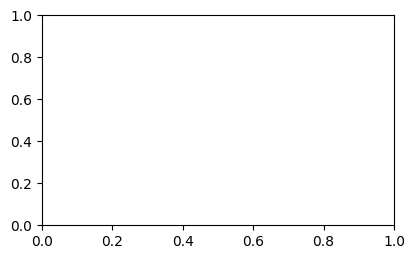

In [10]:
plt.figure(figsize=(10,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.scatter(b.iloc[:,i],b.bal_acc_diff)
    plt.xlabel(b.columns[i])

plt.subplots_adjust(hspace=0.3, wspace=0.3)

### Filtros basados en clasificadores

In [64]:
all_results = pickle.load(open("./results/cla_rand/seed1/5/all_results_classif_cla_rand_1_5.pkl", "rb"))
print(f"Number of datasets: {len(all_results)}")

FileNotFoundError: [Errno 2] No such file or directory: './results/cla_rand/seed1/5/all_results_classif_cla_rand_1_5.pkl'

In [191]:
sum_res = summarize_results(all_results)
sum_res.sample(10)

,dataset,n_instances,n_categorical_features,n_numerical_features,pct_numerical_features,n_classes,method_base,n_invalid_trainings,bal_acc_diff,f1_macro_diff,...,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_method,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,rem_f1_removal_mean
66,newthyroid,215,0,5,100.0,3,CVCFTh,0,0.012698,0.012601,...,0.934286,0.948207,0.970262,0.934286,CVCFTh_cv7_tau0.75,0.960807,0.946984,0.979786,0.946984,NaN
179,german,1000,13,7,35.0,2,Ensemble,0,-0.056190,-0.079305,...,0.633571,0.644903,0.718887,0.633571,Ensemble_cv5,0.565599,0.577381,0.716176,0.577381,0.088205
199,nursery,1296,8,0,0.0,5,IPF,0,-0.122210,-0.153592,...,0.775415,0.804309,0.907672,0.775415,IPF_p3,0.650717,0.653204,0.681338,0.653204,0.326601
193,nursery,1296,8,0,0.0,5,CVCF,0,0.005197,0.003744,...,0.775415,0.804309,0.907672,0.775415,CVCF_cv9,0.808053,0.780612,0.890986,0.780612,NaN
122,monk-2,432,0,6,100.0,2,CVCFTh,0,0.006835,0.006965,...,0.993165,0.993035,0.992958,0.993165,CVCFTh_cv9_tau0.5,1.000000,1.000000,1.000000,1.000000,NaN
82,cleveland,297,0,13,100.0,5,CVCFTh,0,0.037815,0.038692,...,0.280373,0.271515,0.271151,0.280373,CVCFTh_cv5_tau0.5,0.310207,0.318188,0.320350,0.318188,NaN
63,glass,214,0,9,100.0,7,IPF,0,-0.279107,-0.305997,...,0.689921,0.690895,0.753645,0.689921,IPF_p3,0.384898,0.410813,0.397659,0.410813,0.137691
133,led7digit,500,7,0,0.0,10,INFFC,0,-0.011249,-0.010185,...,0.713598,0.709455,0.719375,0.713598,INFFC_cv7,0.699270,0.702349,0.717731,0.702349,0.204997
34,autos,159,10,15,60.0,6,CVCFTh,0,0.049741,0.053427,...,0.789222,0.792545,0.825672,0.789222,CVCFTh_cv9_tau0.75,0.845972,0.838963,0.879631,0.838963,NaN
211,yeast,1484,0,8,100.0,10,Ensemble,0,-0.102914,-0.100571,...,0.566477,0.564850,0.576490,0.566477,Ensemble_cv7,0.464279,0.463563,0.493804,0.463563,0.150011


In [250]:
x = sum_res.apply(lambda x: x.isna().any(), axis=0)
x[x]

rem_mcc_mean                  True
rem_precision_removal_mean    True
rem_f1_removal_mean           True
dtype: bool

In [185]:
sum_res[sum_res.n_instances.isna()].dataset.unique()

array(['hayes-roth', 'monk-2', 'page-blocks'], dtype=object)

#### Lets inspect for invalid filterings

In [27]:
# Check which ds have invalid filterings
mask_ds_with_all_valid_fitlering = np.array([ all_results[i]["classification_df"].valid_classification.all() for i in range(len(all_results))])
# invalid_filtered_dataset_names = 
np.array([e["dataset"] for e in all_results])[~mask_ds_with_all_valid_fitlering]
# invalid_filtered_dataset_names 

array(['autos', 'cleveland', 'german'], dtype='<U13')

De modo que solo hemos encontrado problemas en los datasets *autos*, *cleveland* y *german*.

Veamos más específicamente al aplicar qué filtro:

#### Resultados promedio por filtro sobre todos los datasets (extrayendo la mejor configuración)

In [202]:
sum_res.iloc[:,2:20]

,n_categorical_features,n_numerical_features,pct_numerical_features,n_classes,method_base,n_invalid_trainings,bal_acc_diff,f1_macro_diff,prec_macro_diff,rec_macro_diff,removal_filter,rem_mcc_mean,rem_recall_removal_mean,rem_precision_removal_mean,rem_acc_removal_mean,rem_specificity_mean,rem_removed_pct_mean,baseline_bal_acc
0,16,0,0.0,7,CF,0,0.036508,0.050084,0.047143,0.036508,CF_DT_cv3,0.492131,1.000000,0.273349,0.896019,0.891661,14.361111,0.906349
1,16,0,0.0,7,CVCF,0,0.019048,0.035004,0.042857,0.019048,CVCF_cv3,0.395082,0.350000,0.516667,0.960309,0.984412,2.975309,0.906349
2,16,0,0.0,7,CVCFTh,0,0.028571,0.033333,0.033333,0.028571,CVCFTh_cv3_tau0.5,0.395082,0.350000,0.516667,0.960309,0.984412,2.975309,0.906349
3,16,0,0.0,7,Ensemble,0,0.005556,0.012857,0.019841,0.005556,Ensemble_cv3,0.538139,1.000000,0.320657,0.915864,0.912376,12.376543,0.906349
4,16,0,0.0,7,EnsembleTh,0,-0.011111,-0.000449,0.000582,-0.011111,EnsembleTh_cv3_tau0.5,0.538139,1.000000,0.320657,0.915864,0.912376,12.376543,0.906349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,0,20,100.0,2,Ensemble,0,0.000811,0.000811,0.000830,0.000811,Ensemble_cv3,0.562150,0.979920,0.339039,0.954324,0.953701,6.837838,0.970807
300,0,20,100.0,2,EnsembleTh,0,0.001892,0.001892,0.001876,0.001892,EnsembleTh_cv3_tau0.5,0.562150,0.979920,0.339039,0.954324,0.953701,6.837838,0.970807
301,0,20,100.0,2,INFFC,0,-0.002703,-0.002703,-0.002685,-0.002703,INFFC_cv3,0.415907,0.995515,0.193426,0.901723,0.899445,12.172297,0.970807
302,0,20,100.0,2,INFFCTh,0,0.000541,0.000540,0.000571,0.000541,INFFCTh_cv3_tau0.5,0.415907,0.995515,0.193426,0.901723,0.899445,12.172297,0.970807


In [213]:
def df_to_tblr(df):
    df = df.copy()
    num_cols = df.columns[1:]
    max_vals = df[num_cols].max(numeric_only=True)

    def fmt(col, val):
        if pd.isna(val):
            return ""
        s = f"{val:.6f}" if pd.api.types.is_numeric_dtype(df[col]) else str(val)
        return rf"\textbf{{{s}}}" if col in max_vals.index and np.isclose(val, max_vals[col]) else s

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"    \centering")
    lines.append(r"    \begin{tblr}{")
    lines.append(r"      row{2} = {font=\bfseries},")
    lines.append(r"      cell{1}{2} = {c=4}{c},")
    lines.append(r"      cell{1}{6} = {c=4}{c},")
    lines.append(r"      vline{3} = {1}{},")
    lines.append(r"      vline{2,6} = {2-" + str(len(df) + 2) + r"}{},")
    lines.append(r"      hline{2-3," + str(len(df) + 2) + r"} = {-}{},")
    lines.append(r"    }")
    lines.append(r"               & Clasificación &           &             & Limpieza &          &          &           \\")
    lines.append(r"    Filtro     & acc      & bal\_acc      & f1\_macro & prec\_macro & acc      & prec     & recall   & pct       \\")

    for _, row in df.iterrows():
        vals = [fmt(col, row[col]) for col in df.columns[1:]]
        lines.append(f"    {row[df.columns[0]]:<10} & " + " & ".join(vals) + r" \\")
    
    lines.append(r"    \end{tblr}")
    lines.append(r"    \caption{}")
    lines.append(rf"    \label{{tab:classif_cla_rand_5}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)
tabla = (
    sum_res[
        ["method_base","class_acc","bal_acc_diff","f1_macro_diff","prec_macro_diff",
         "rem_acc_removal_mean","rem_precision_removal_mean",
         "rem_recall_removal_mean","rem_removed_pct_mean"]
    ]
    .groupby("method_base")
    .mean()
    .reset_index()
    .rename(columns={
        "method_base": "Filtro",
        "bal_acc_diff": "bal_acc",
        "f1_macro_diff": "f1_macro",
        "prec_macro_diff": "prec_macro",
        "rem_acc_removal_mean": "acc",
        "rem_precision_removal_mean": "prec",
        "rem_recall_removal_mean": "recall",
        "rem_removed_pct_mean": "pct",
    })
)
display(tabla)
latex = df_to_tblr(tabla)
print(latex)

,Filtro,bal_acc,f1_macro,prec_macro,acc,prec,recall,pct
0,CF,0.000628,0.001872,0.005347,0.789368,0.171798,0.892826,23.926145
1,CVCF,0.009418,0.009852,0.010703,0.954921,0.293684,0.063813,1.586926
2,CVCFTh,0.011632,0.012607,0.013446,0.954921,0.293684,0.063813,1.586926
3,Ensemble,-0.032710,-0.031200,-0.018261,0.799353,0.205352,0.957590,23.311671
4,EnsembleTh,-0.013673,-0.012486,-0.004690,0.799353,0.205352,0.957590,23.311671
5,INFFC,-0.088994,-0.094314,-0.077172,0.724669,0.157232,0.979176,30.896841
6,INFFCTh,-0.045570,-0.046936,-0.025421,0.724665,0.157231,0.979176,30.897288
7,IPF,-0.078474,-0.086116,-0.081434,0.762107,0.226612,0.956392,27.023698


\begin{table}[htbp]
    \centering
    \begin{tblr}{
      row{2} = {font=\bfseries},
      cell{1}{2} = {c=3}{c},
      cell{1}{5} = {c=4}{c},
      vline{3} = {1}{},
      vline{2,5} = {2-10}{},
      hline{2-3,10} = {-}{},
    }
               & Clasificación &           &             & Limpieza &          &          &           \\
    Filtro     & bal\_acc      & f1\_macro & prec\_macro & acc      & prec     & recall   & pct       \\
    CF         & 0.000628 & 0.001872 & 0.005347 & 0.789368 & 0.171798 & 0.892826 & 23.926145 \\
    CVCF       & 0.009418 & 0.009852 & 0.010703 & \textbf{0.954921} & \textbf{0.293684} & 0.063813 & 1.586926 \\
    CVCFTh     & \textbf{0.011632} & \textbf{0.012607} & \textbf{0.013446} & \textbf{0.954921} & \textbf{0.293684} & 0.063813 & 1.586926 \\
    Ensemble   & -0.032710 & -0.031200 & -0.018261 & 0.799353 & 0.205352 & 0.957590 & 23.311671 \\
    EnsembleTh & -0.013673 & -0.012486 & -0.004690 & 0.799353 & 0.205352 & 0.957590 & 23.311671 \\
    INFFC  

In [189]:
sum_res.drop(["n_instances","n_categorical_features", "n_numerical_features", "n_classes","dataset","class_method", "removal_filter"], axis=1).groupby("method_base").mean()

,pct_numerical_features,n_invalid_trainings,bal_acc_diff,f1_macro_diff,prec_macro_diff,rec_macro_diff,rem_mcc_mean,rem_recall_removal_mean,rem_precision_removal_mean,rem_acc_removal_mean,...,rem_removed_pct_mean,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,rem_f1_removal_mean
method_base,,,,,,,,,,,,,,,,,,,,,
CF,76.700206,0.000000,0.000628,0.001872,0.005347,0.002199,0.329751,0.892826,0.171798,0.789368,...,23.926145,0.809005,0.808945,0.822488,0.807435,0.810817,0.809634,0.827835,0.809634,0.277487
CVCF,76.700206,0.000000,0.009418,0.009852,0.010703,0.009509,0.145373,0.063813,0.293684,0.954921,...,1.586926,0.809005,0.808945,0.822488,0.807435,0.818797,0.818423,0.833191,0.816944,0.166060
CVCFTh,76.700206,0.000000,0.011632,0.012607,0.013446,0.011635,0.145373,0.063813,0.293684,0.954921,...,1.586926,0.809005,0.808945,0.822488,0.807435,0.821552,0.820637,0.835934,0.819069,0.166060
Ensemble,76.700206,0.000000,-0.032710,-0.031200,-0.018261,-0.031140,0.379335,0.957590,0.205352,0.799353,...,23.311671,0.809005,0.808945,0.822488,0.807435,0.777745,0.776295,0.804227,0.776295,0.319327
EnsembleTh,76.700206,0.000000,-0.013673,-0.012486,-0.004690,-0.012102,0.379335,0.957590,0.205352,0.799353,...,23.311671,0.809005,0.808945,0.822488,0.807435,0.796459,0.795332,0.817798,0.795332,0.319327
INFFC,76.700206,0.026316,-0.088994,-0.094314,-0.077172,-0.087756,0.318414,0.979176,0.157232,0.724669,...,30.896841,0.809005,0.808945,0.822488,0.807435,0.714631,0.720011,0.745316,0.719679,0.254799
INFFCTh,76.700206,0.026316,-0.045570,-0.046936,-0.025421,-0.044457,0.318413,0.979176,0.157231,0.724665,...,30.897288,0.809005,0.808945,0.822488,0.807435,0.762009,0.763435,0.797067,0.762978,0.254798
IPF,76.700206,0.052632,-0.078474,-0.086116,-0.081434,-0.077845,0.376826,0.956392,0.226612,0.762107,...,27.023698,0.809005,0.808945,0.822488,0.807435,0.722829,0.730531,0.741054,0.729590,0.323421


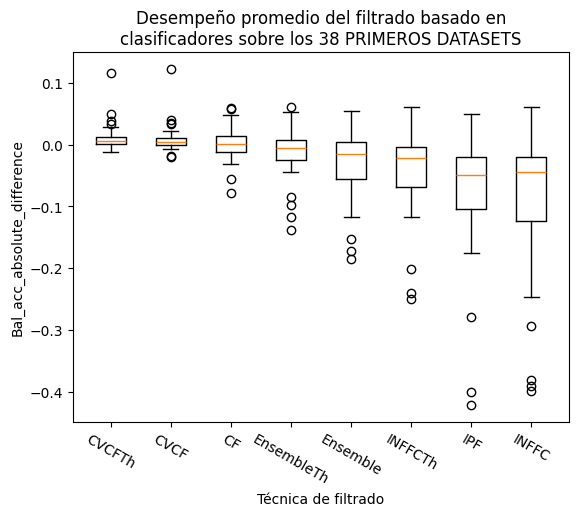

In [278]:
classif_filter_names = sorted(
    list(sum_res.method_base.unique()),
    key=lambda x: -tabla.loc[tabla.Filtro == x, "bal_acc"].iat[0]
)
plt.boxplot([
    sum_res[(sum_res.method_base==mb)].bal_acc_diff
    for mb in classif_filter_names
    ],
    manage_ticks=False
)
plt.xlabel("Técnica de filtrado")
plt.ylabel("Bal_acc_absolute_difference")
plt.xticks(np.arange(1, len(classif_filter_names)+1), labels = classif_filter_names, rotation=-30)
plt.title("Desempeño promedio del filtrado basado en\nclasificadores sobre los 38 PRIMEROS DATASETS")
plt.savefig("./figs/bp_classif_cla_rand_5.png")
plt.show()

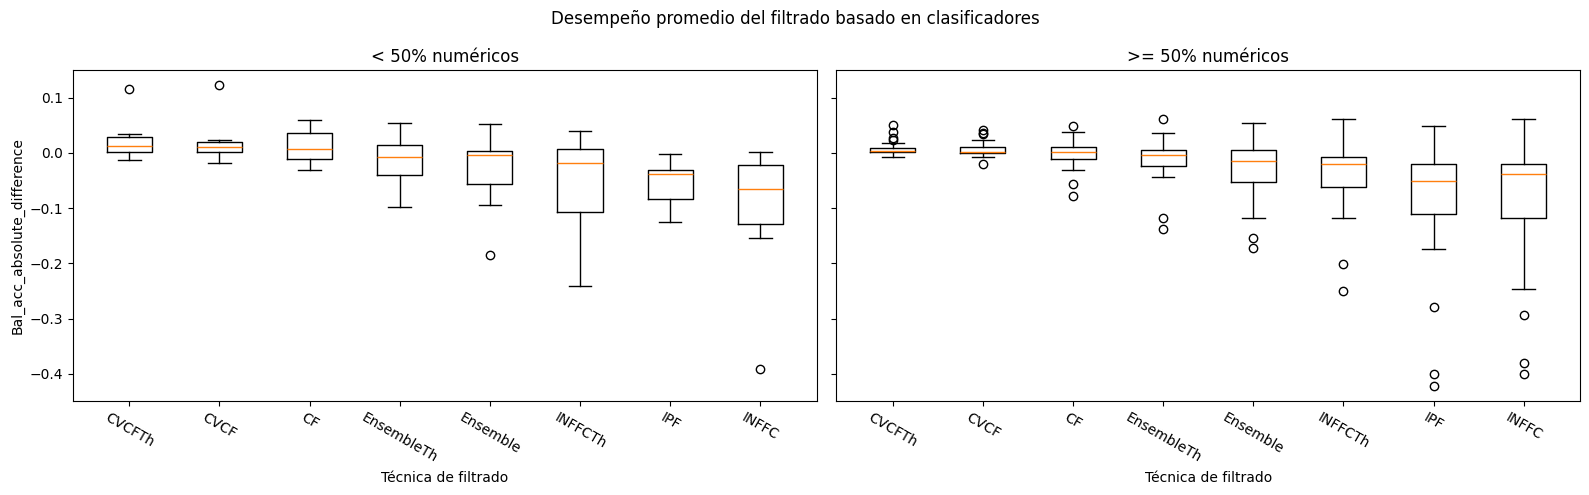

In [279]:
classif_filter_names = sorted(
    list(sum_res.method_base.unique()),
    key=lambda x: -tabla.loc[tabla.Filtro == x, "bal_acc"].iat[0]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

groups = [
    ("< 50% numéricos", sum_res.pct_numerical_features < 50),
    (">= 50% numéricos", sum_res.pct_numerical_features >= 50),
]

for ax, (title, mask) in zip(axes, groups):
    ax.boxplot(
        [sum_res[mask & (sum_res.method_base == mb)].bal_acc_diff for mb in classif_filter_names],
        manage_ticks=False
    )
    ax.set_xticks(np.arange(1, len(classif_filter_names) + 1))
    ax.set_xticklabels(classif_filter_names, rotation=-30)
    ax.set_xlabel("Técnica de filtrado")
    ax.set_title(title)

axes[0].set_ylabel("Bal_acc_absolute_difference")
fig.suptitle("Desempeño promedio del filtrado basado en clasificadores")
plt.tight_layout()
plt.savefig("./figs/bp_classif_cla_rand_5_split_numeric.png")
plt.show()

In [ ]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

rows = []

for mb, g in sum_res.groupby("method_base"):
    vals = g["bal_acc_diff"].dropna()

    if len(vals) == 0 or np.allclose(vals, 0):
        pval = np.nan
    else:
        try:
            pval = wilcoxon(vals, alternative="two-sided").pvalue
        except ValueError:
            pval = np.nan

    rows.append({
        "Filtro": mb,
        "bal_acc": vals.mean(),
        "p_value": pval,
    })

tabla_w = pd.DataFrame(rows)

display(tabla_w)
def fmt_p(x):
    if pd.isna(x):
        return ""
    s = f"{x:.2e}"
    return rf"\textbf{{{s}}}" if x < 0.05 else s

print(
    tabla_w.sort_values("bal_acc", ascending=False).to_latex(
        index=False,
        escape=False,
        formatters={
            "bal_acc": lambda x: f"{x:.6f}",
            "p_value": fmt_p,
        },
    )
)

,Filtro,bal_acc,p_value
0,CF,0.000628,9.364253e-01
1,CVCF,0.009418,7.260713e-04
2,CVCFTh,0.011632,1.346898e-05
3,Ensemble,-0.032710,1.385200e-03
4,EnsembleTh,-0.013673,8.684261e-02
5,INFFC,-0.088994,4.803587e-08
6,INFFCTh,-0.045570,2.641165e-05
7,IPF,-0.078474,1.079025e-08


\begin{tabular}{lrr}
\toprule
Filtro & bal_acc & p_value \\
\midrule
CVCFTh & 0.011632 & \textbf{1.35e-05} \\
CVCF & 0.009418 & \textbf{7.26e-04} \\
CF & 0.000628 & 9.36e-01 \\
EnsembleTh & -0.013673 & 8.68e-02 \\
Ensemble & -0.032710 & \textbf{1.39e-03} \\
INFFCTh & -0.045570 & \textbf{2.64e-05} \\
IPF & -0.078474 & \textbf{1.08e-08} \\
INFFC & -0.088994 & \textbf{4.80e-08} \\
\bottomrule
\end{tabular}



#### Otras pruebas

In [276]:
x = all_results[0]["classification_df"]
x[x.method.map(lambda s: s.split("_")[0])=="IPF"]

,experiment,dataset,noise_type,noise_pct,seed,k,fold,method,encoding,test_source,preprocess_before_filter,n_train_input,n_train_used,n_test,valid_classification,params,bal_acc,f1_macro,precision_macro,recall_macro
260,zoo|cla_rand|25|IPF_p3,zoo,cla_rand,25,1,25,1,IPF_p3,onehot,clean,True,80,47,21,True,"{'preprocess_before_filter': True, 'preprocess...",0.571429,0.500000,0.476190,0.571429
261,zoo|cla_rand|25|IPF_p3,zoo,cla_rand,25,1,25,2,IPF_p3,onehot,clean,True,81,55,20,True,"{'preprocess_before_filter': True, 'preprocess...",0.785714,0.753501,0.769841,0.785714
262,zoo|cla_rand|25|IPF_p3,zoo,cla_rand,25,1,25,3,IPF_p3,onehot,clean,True,81,58,20,True,"{'preprocess_before_filter': True, 'preprocess...",0.785714,0.714286,0.714286,0.785714
263,zoo|cla_rand|25|IPF_p3,zoo,cla_rand,25,1,25,4,IPF_p3,onehot,clean,True,81,60,20,True,"{'preprocess_before_filter': True, 'preprocess...",0.666667,0.592593,0.550000,0.666667
264,zoo|cla_rand|25|IPF_p3,zoo,cla_rand,25,1,25,5,IPF_p3,onehot,clean,True,81,49,20,True,"{'preprocess_before_filter': True, 'preprocess...",0.571429,0.481633,0.438095,0.571429
265,zoo|cla_rand|25|IPF_p5,zoo,cla_rand,25,1,25,1,IPF_p5,onehot,clean,True,80,48,21,True,"{'preprocess_before_filter': True, 'preprocess...",0.428571,0.328571,0.285714,0.428571
266,zoo|cla_rand|25|IPF_p5,zoo,cla_rand,25,1,25,2,IPF_p5,onehot,clean,True,81,45,20,True,"{'preprocess_before_filter': True, 'preprocess...",0.571429,0.484848,0.438776,0.571429
267,zoo|cla_rand|25|IPF_p5,zoo,cla_rand,25,1,25,3,IPF_p5,onehot,clean,True,81,42,20,True,"{'preprocess_before_filter': True, 'preprocess...",0.428571,0.360544,0.321429,0.428571
268,zoo|cla_rand|25|IPF_p5,zoo,cla_rand,25,1,25,4,IPF_p5,onehot,clean,True,81,56,20,True,"{'preprocess_before_filter': True, 'preprocess...",0.666667,0.523810,0.500000,0.571429
269,zoo|cla_rand|25|IPF_p5,zoo,cla_rand,25,1,25,5,IPF_p5,onehot,clean,True,81,37,20,True,"{'preprocess_before_filter': True, 'preprocess...",0.428571,0.345055,0.301587,0.428571


In [260]:
sum_res[sum_res.method_base=="IPF"]

,dataset,n_instances,n_categorical_features,n_numerical_features,pct_numerical_features,n_classes,method_base,n_invalid_trainings,bal_acc_diff,f1_macro_diff,...,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_method,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,rem_f1_removal_mean
7,zoo,101,16,0,0.000000,7,IPF,0,-0.125397,-0.173726,...,0.906349,0.885556,0.897619,0.906349,IPF_p3,0.711830,0.780952,0.711429,0.757143,0.382772
15,hayes-roth,132,0,4,100.000000,3,IPF,0,-0.174949,-0.169245,...,0.815758,0.823514,0.837003,0.815758,IPF_p3,0.654269,0.640808,0.733587,0.640808,0.202261
23,lymphography,148,15,3,16.666667,4,IPF,0,-0.037962,-0.044300,...,0.575080,0.564951,0.563018,0.575080,IPF_p3,0.520651,0.537118,0.539604,0.537118,0.138791
31,iris,150,0,4,100.000000,3,IPF,0,-0.006667,-0.006751,...,0.960000,0.959933,0.961077,0.960000,IPF_p7,0.953182,0.953333,0.956162,0.953333,0.609304
39,autos,159,10,15,60.000000,6,IPF,0,-0.400222,-0.452584,...,0.789222,0.792545,0.825672,0.789222,IPF_p3,0.339962,0.389000,0.337690,0.377037,0.169759
47,wine,178,0,13,100.000000,3,IPF,0,-0.013968,-0.016414,...,0.981270,0.978277,0.977016,0.981270,IPF_p5,0.961864,0.967302,0.962137,0.967302,0.422397
55,sonar,208,0,60,100.000000,2,IPF,0,-0.066148,-0.065230,...,0.811598,0.811023,0.815337,0.811598,IPF_p9,0.745793,0.745449,0.770804,0.745449,0.113535
63,glass,214,0,9,100.000000,7,IPF,0,-0.279107,-0.305997,...,0.689921,0.690895,0.753645,0.689921,IPF_p3,0.384898,0.410813,0.397659,0.410813,0.137691
71,newthyroid,215,0,5,100.000000,3,IPF,0,-0.078095,-0.066089,...,0.934286,0.948207,0.970262,0.934286,IPF_p3,0.882118,0.856190,0.925702,0.856190,0.582215
79,heart,270,0,13,100.000000,2,IPF,0,-0.081667,-0.084301,...,0.819167,0.819123,0.825120,0.819167,IPF_p3,0.734822,0.737500,0.752471,0.737500,0.175354


In [248]:
x = {mb:sum_res[sum_res.method_base==mb].bal_acc_diff for mb in classif_filter_names}
x["IPF"]

7     -0.125397
15    -0.174949
23    -0.037962
31    -0.006667
39    -0.400222
47    -0.013968
55    -0.066148
63    -0.279107
71    -0.078095
79    -0.081667
87    -0.004034
95    -0.036414
103   -0.159310
111   -0.046188
119   -0.004259
127    0.002487
135   -0.002900
143   -0.043663
151   -0.038294
159   -0.019648
167   -0.110159
175   -0.422222
183   -0.083968
191   -0.030473
199   -0.122210
207    0.048893
215   -0.130996
223   -0.051296
231   -0.117901
239   -0.022944
247   -0.020365
255   -0.002137
263   -0.085937
271   -0.028535
279   -0.065725
287    0.007353
295   -0.050738
303   -0.076227
Name: bal_acc_diff, dtype: float64

### cncnos


In [9]:
all_results = pickle.load(open("./results/cla_rand/seed1/5/all_results_cncnos_cla_rand_1_5.pkl", "rb"))
print(f"Number of datasets: {len(all_results)}")

Number of datasets: 30


/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/base.py:463: Inconsi

In [282]:
sum_res = summarize_results(all_results)
sum_res.sample(10)

,dataset,n_instances,n_categorical_features,n_numerical_features,pct_numerical_features,n_classes,method_base,n_invalid_trainings,bal_acc_diff,f1_macro_diff,...,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_method,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,rem_f1_removal_mean
1,hayes-roth,132,0,4,100.000000,3,CNCNOS,0,-0.026061,-0.031645,...,0.560404,0.562012,0.597670,0.560404,CNCNOS_default,0.530366,0.534343,0.622486,0.534343,0.130770
12,ecoli,336,0,7,100.000000,8,CNCNOS,0,-0.027883,-0.024454,...,0.685977,0.661513,0.674607,0.685977,CNCNOS_default,0.637059,0.658094,0.668886,0.641593,0.081342
4,autos,159,10,15,60.000000,6,CNCNOS,0,-0.161444,-0.131378,...,0.706000,0.663727,0.669944,0.684481,CNCNOS_default,0.532348,0.544556,0.578848,0.544556,0.237240
5,wine,178,0,13,100.000000,3,CNCNOS,0,0.006190,0.004399,...,0.965873,0.962569,0.964733,0.965873,CNCNOS_default,0.966968,0.972063,0.966410,0.972063,0.414141
15,monk-2,432,0,6,100.000000,2,CNCNOS,0,0.025367,0.023748,...,0.769141,0.769164,0.772549,0.769141,CNCNOS_default,0.792912,0.794508,0.797136,0.794508,0.151634
9,heart,270,0,13,100.000000,2,CNCNOS,0,0.020000,0.021422,...,0.838333,0.838259,0.841562,0.838333,CNCNOS_default,0.859680,0.858333,0.868195,0.858333,0.206895
6,sonar,208,0,60,100.000000,2,CNCNOS,0,-0.002225,-0.000232,...,0.755551,0.753890,0.756787,0.755551,CNCNOS_default,0.753658,0.753326,0.768470,0.753326,0.185256
11,splice,319,60,0,0.000000,3,CNCNOS,0,-0.124747,-0.207885,...,0.850581,0.853527,0.858993,0.850581,CNCNOS_default,0.645642,0.725833,0.692238,0.725833,0.103105
3,iris,150,0,4,100.000000,3,CNCNOS,0,0.033333,0.033417,...,0.933333,0.933166,0.935354,0.933333,CNCNOS_default,0.966583,0.966667,0.968350,0.966667,0.361111
2,lymphography,148,15,3,16.666667,4,CNCNOS,0,0.041217,0.062948,...,0.763969,0.738392,0.737529,0.763969,CNCNOS_default,0.801339,0.805186,0.813118,0.805186,NaN


In [283]:
def df_to_tblr(df):
    df = df.copy()
    num_cols = df.columns[1:]
    max_vals = df[num_cols].max(numeric_only=True)

    def fmt(col, val):
        if pd.isna(val):
            return ""
        s = f"{val:.6f}" if pd.api.types.is_numeric_dtype(df[col]) else str(val)
        return rf"\textbf{{{s}}}" if col in max_vals.index and np.isclose(val, max_vals[col]) else s

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"    \centering")
    lines.append(r"    \begin{tblr}{")
    lines.append(r"      row{2} = {font=\bfseries},")
    lines.append(r"      cell{1}{2} = {c=4}{c},")
    lines.append(r"      cell{1}{6} = {c=4}{c},")
    lines.append(r"      vline{3} = {1}{},")
    lines.append(r"      vline{2,6} = {2-" + str(len(df) + 2) + r"}{},")
    lines.append(r"      hline{2-3," + str(len(df) + 2) + r"} = {-}{},")
    lines.append(r"    }")
    lines.append(r"               & Clasificación &           &             & Limpieza &          &          &           \\")
    lines.append(r"    Filtro     & acc      & bal\_acc      & f1\_macro & prec\_macro & acc      & prec     & recall   & pct       \\")

    for _, row in df.iterrows():
        vals = [fmt(col, row[col]) for col in df.columns[1:]]
        lines.append(f"    {row[df.columns[0]]:<10} & " + " & ".join(vals) + r" \\")
    
    lines.append(r"    \end{tblr}")
    lines.append(r"    \caption{}")
    lines.append(rf"    \label{{tab:classif_cla_rand_5}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)
tabla = (
    sum_res[
        ["method_base","bal_acc_diff","f1_macro_diff","prec_macro_diff",
         "rem_acc_removal_mean","rem_precision_removal_mean",
         "rem_recall_removal_mean","rem_removed_pct_mean"]
    ]
    .groupby("method_base")
    .mean()
    .reset_index()
    .rename(columns={
        "method_base": "Filtro",
        "bal_acc_diff": "bal_acc",
        "f1_macro_diff": "f1_macro",
        "prec_macro_diff": "prec_macro",
        "rem_acc_removal_mean": "acc",
        "rem_precision_removal_mean": "prec",
        "rem_recall_removal_mean": "recall",
        "rem_removed_pct_mean": "pct",
    })
)
display(tabla)
latex = df_to_tblr(tabla)
print(latex)

,Filtro,bal_acc,f1_macro,prec_macro,acc,prec,recall,pct
0,CNCNOS,-0.033044,-0.039071,-0.030116,0.874867,0.164296,0.36119,11.790776


\begin{table}[htbp]
    \centering
    \begin{tblr}{
      row{2} = {font=\bfseries},
      cell{1}{2} = {c=3}{c},
      cell{1}{5} = {c=4}{c},
      vline{3} = {1}{},
      vline{2,5} = {2-3}{},
      hline{2-3,3} = {-}{},
    }
               & Clasificación &           &             & Limpieza &          &          &           \\
    Filtro     & bal\_acc      & f1\_macro & prec\_macro & acc      & prec     & recall   & pct       \\
    CNCNOS     & \textbf{-0.033044} & \textbf{-0.039071} & \textbf{-0.030116} & \textbf{0.874867} & \textbf{0.164296} & \textbf{0.361190} & \textbf{11.790776} \\
    \end{tblr}
    \caption{}
    \label{tab:classif_cla_rand_5}
\end{table}


## Medium noise (25%)

### Filtros basados en distancia <b style="color:red">COMPLETAR SIMULACIONES desde 18</b>

In [11]:
all_results = pickle.load(open("./results/cla_rand/seed1/25/all_results_dists_cla_rand_1_25.pkl", "rb"))
len(all_results)

ModuleNotFoundError: No module named 'sklearn'

In [13]:
summarize_results(all_results)

,dataset,n_instances,n_categorical_features,n_numerical_features,n_classes,method_base,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,...,class_precision_macro_mean,class_recall_macro_mean,removal_filter,removal_f1_removal_mean,removal_mcc_mean,removal_recall_removal_mean,removal_precision_removal_mean,removal_acc_removal_mean,removal_specificity_mean,removal_removed_pct_mean
0,zoo,101.0,16.0,0.0,7.0,ENN,0.842659,0.806477,0.801984,0.842659,...,0.707143,0.757143,ENN_k1,0.558103,0.418558,0.739708,0.449187,0.747438,0.748711,35.654321
1,zoo,101.0,16.0,0.0,7.0,ENNProb,0.842659,0.806477,0.801984,0.842659,...,0.746508,0.764286,ENNProb_k1,0.558103,0.418558,0.739708,0.449187,0.747438,0.748711,35.654321
2,zoo,101.0,16.0,0.0,7.0,ENNTh,0.842659,0.806477,0.801984,0.842659,...,0.676746,0.728770,ENNTh_k1_tau0.5,0.558103,0.418558,0.739708,0.449187,0.747438,0.748711,35.654321
3,zoo,101.0,16.0,0.0,7.0,MENN,0.842659,0.806477,0.801984,0.842659,...,0.718254,0.757143,MENN_k1,0.707980,0.628222,0.871871,0.596574,0.846451,0.837884,31.685185
4,zoo,101.0,16.0,0.0,7.0,NCNEdit,0.842659,0.806477,0.801984,0.842659,...,0.659392,0.719048,NCNEdit_k1,0.610366,0.486265,0.764678,0.510077,0.782315,0.786832,33.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,segment,2310.0,0.0,19.0,7.0,ENN,0.928571,0.928739,0.930495,0.928571,...,0.964437,0.963636,ENN_k1,0.665393,0.576676,0.888149,0.532029,0.807035,0.784638,36.071429
146,segment,2310.0,0.0,19.0,7.0,ENNProb,0.928571,0.928739,0.930495,0.928571,...,0.962769,0.961905,ENNProb_k1,0.665393,0.576676,0.888149,0.532029,0.807035,0.784638,36.071429
147,segment,2310.0,0.0,19.0,7.0,ENNTh,0.928571,0.928739,0.930495,0.928571,...,0.963620,0.962771,ENNTh_k1_tau0.5,0.665393,0.576676,0.888149,0.532029,0.807035,0.784638,36.071429
148,segment,2310.0,0.0,19.0,7.0,MENN,0.928571,0.928739,0.930495,0.928571,...,0.965114,0.964502,MENN_k1,0.657741,0.566144,0.882207,0.524418,0.801623,0.779396,36.352814


In [7]:
x = summarize_results(all_results)
x.drop(["dataset","class_method", "removal_filter"], axis=1).groupby("method_base").mean()

,n_instances,n_categorical_features,n_numerical_features,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,removal_f1_removal_mean,removal_mcc_mean,removal_recall_removal_mean,removal_precision_removal_mean,removal_acc_removal_mean,removal_specificity_mean,removal_removed_pct_mean
method_base,,,,,,,,,,,,,,,,,,
ENN,719.071429,6.392857,10.75,0.748972,0.732481,0.745501,0.73715,0.711084,0.715924,0.735590,0.714665,0.494156,0.385779,0.826107,0.357212,0.695589,0.662789,42.456658
ENNProb,719.071429,6.392857,10.75,0.748972,0.732481,0.745501,0.73715,0.716556,0.721481,0.741043,0.720284,0.494584,0.386187,0.826012,0.357617,0.696188,0.663622,42.371417
ENNTh,719.071429,6.392857,10.75,0.748972,0.732481,0.745501,0.73715,0.710950,0.716149,0.733365,0.715683,0.494584,0.386187,0.826012,0.357617,0.696188,0.663622,42.371417
MENN,719.071429,6.392857,10.75,0.748972,0.732481,0.745501,0.73715,0.713619,0.718848,0.737284,0.717589,0.508376,0.406956,0.838257,0.370568,0.707548,0.675038,41.750241
NCNEdit,719.071429,6.392857,10.75,0.748972,0.732481,0.745501,0.73715,0.714493,0.719870,0.739246,0.718875,0.497807,0.391094,0.829360,0.360691,0.698470,0.665701,42.280425


In [ ]:
x[]

,dataset,n_instances,n_categorical_features,n_numerical_features,method_base,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_method,...,class_precision_macro_mean,class_recall_macro_mean,removal_filter,removal_f1_removal_mean,removal_mcc_mean,removal_recall_removal_mean,removal_precision_removal_mean,removal_acc_removal_mean,removal_specificity_mean,removal_removed_pct_mean
0,zoo,101.0,16.0,0.0,ENN,0.842659,0.806477,0.801984,0.842659,ENN_k5,...,0.707143,0.757143,ENN_k1,0.558103,0.418558,0.739708,0.449187,0.747438,0.748711,35.654321
1,zoo,101.0,16.0,0.0,ENNProb,0.842659,0.806477,0.801984,0.842659,ENNProb_k5,...,0.746508,0.764286,ENNProb_k1,0.558103,0.418558,0.739708,0.449187,0.747438,0.748711,35.654321
2,zoo,101.0,16.0,0.0,ENNTh,0.842659,0.806477,0.801984,0.842659,ENNTh_k1_tau0.5,...,0.676746,0.728770,ENNTh_k1_tau0.5,0.558103,0.418558,0.739708,0.449187,0.747438,0.748711,35.654321
3,zoo,101.0,16.0,0.0,MENN,0.842659,0.806477,0.801984,0.842659,MENN_k5,...,0.718254,0.757143,MENN_k1,0.707980,0.628222,0.871871,0.596574,0.846451,0.837884,31.685185
4,zoo,101.0,16.0,0.0,NCNEdit,0.842659,0.806477,0.801984,0.842659,NCNEdit_k1,...,0.659392,0.719048,NCNEdit_k1,0.610366,0.486265,0.764678,0.510077,0.782315,0.786832,33.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,segment,2310.0,0.0,19.0,ENN,0.928571,0.928739,0.930495,0.928571,ENN_k1,...,0.964437,0.963636,ENN_k1,0.665393,0.576676,0.888149,0.532029,0.807035,0.784638,36.071429
146,segment,2310.0,0.0,19.0,ENNProb,0.928571,0.928739,0.930495,0.928571,ENNProb_k3,...,0.962769,0.961905,ENNProb_k1,0.665393,0.576676,0.888149,0.532029,0.807035,0.784638,36.071429
147,segment,2310.0,0.0,19.0,ENNTh,0.928571,0.928739,0.930495,0.928571,ENNTh_k1_tau0.5,...,0.963620,0.962771,ENNTh_k1_tau0.5,0.665393,0.576676,0.888149,0.532029,0.807035,0.784638,36.071429
148,segment,2310.0,0.0,19.0,MENN,0.928571,0.928739,0.930495,0.928571,MENN_k1,...,0.965114,0.964502,MENN_k1,0.657741,0.566144,0.882207,0.524418,0.801623,0.779396,36.352814


In [14]:
summarize_results(all_results)

,dataset,method_base,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_method,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,removal_filter,removal_f1_removal_mean,removal_mcc_mean,removal_recall_removal_mean,removal_precision_removal_mean,removal_acc_removal_mean,removal_specificity_mean,removal_removed_pct_mean
0,autos,ENN,0.728556,0.697936,0.761337,0.728556,ENN_k9,0.346879,0.399778,0.332139,0.399778,ENN_k1,0.530115,0.407309,0.943016,0.368958,0.632087,0.544431,56.289370
1,autos,ENNProb,0.728556,0.697936,0.761337,0.728556,ENNProb_k3,0.355603,0.412259,0.354919,0.399778,ENNProb_k1,0.530115,0.407309,0.943016,0.368958,0.632087,0.544431,56.289370
2,autos,ENNTh,0.728556,0.697936,0.761337,0.728556,ENNTh_k1_tau0.5,0.344329,0.394481,0.347898,0.382000,ENNTh_k1_tau0.5,0.530115,0.407309,0.943016,0.368958,0.632087,0.544431,56.289370
3,autos,MENN,0.728556,0.697936,0.761337,0.728556,MENN_k9,0.346879,0.399778,0.332139,0.399778,MENN_k1,0.530115,0.407309,0.943016,0.368958,0.632087,0.544431,56.289370
4,autos,MultiEdit,0.728556,0.697936,0.761337,0.728556,MultiEdit_k1_b3,0.368631,0.408667,0.397833,0.397074,MultiEdit_k1_b3,0.460290,0.290642,0.914392,0.307636,0.528334,0.419323,65.407234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,led7digit,ENNProb,0.678867,0.678347,0.705494,0.678867,ENNProb_k5,0.695435,0.698854,0.720277,0.698854,ENNProb_k1,0.457005,0.265978,0.763976,0.326263,0.603000,0.558037,51.200000
57,led7digit,ENNTh,0.678867,0.678347,0.705494,0.678867,ENNTh_k9_tau0.5,0.685266,0.699348,0.706717,0.699348,ENNTh_k1_tau0.5,0.457005,0.265978,0.763976,0.326263,0.603000,0.558037,51.200000
58,led7digit,MENN,0.678867,0.678347,0.705494,0.678867,MENN_k15,0.739224,0.748110,0.751570,0.748110,MENN_k1,0.613807,0.505615,0.865041,0.475880,0.762500,0.733956,39.650000
59,led7digit,MultiEdit,0.678867,0.678347,0.705494,0.678867,MultiEdit_k5_b5,0.748351,0.757393,0.760842,0.757393,MultiEdit_k1_b3,0.490116,0.346410,0.933530,0.332633,0.575000,0.475104,61.400000


### Filtros basados en clasificadores

In [10]:
all_results = pickle.load(open("./results/cla_rand/seed1/25/all_results_classif_cla_rand_1_25.pkl", "rb"))
len(all_results)

ModuleNotFoundError: No module named 'sklearn'

In [59]:
all_results = {dataset_name:all_results[i] for i,dataset_name in enumerate(keel_datasets)}

In [60]:
all_results.keys()

dict_keys(['autos', 'balance', 'banana', 'car', 'cleveland', 'contraceptive', 'dermatology', 'ecoli', 'flare', 'german', 'glass', 'hayes-roth', 'heart', 'ionosphere', 'iris', 'led7digit', 'lymphography', 'magic', 'monk-2', 'newthyroid', 'nursery', 'page-blocks', 'penbased', 'phoneme', 'pima', 'ring', 'satimage', 'segment', 'shuttle', 'sonar', 'spambase', 'splice', 'thyroid', 'twonorm', 'vehicle', 'vowel', 'wdbc', 'wine', 'yeast', 'zoo'])

In [28]:
x = summarize_results(all_results).drop(["dataset","class_method", "removal_filter"], axis=1).groupby("method_base").mean()
x

,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,removal_f1_removal_mean,removal_mcc_mean,removal_recall_removal_mean,removal_precision_removal_mean,removal_acc_removal_mean,removal_specificity_mean,removal_removed_pct_mean
method_base,,,,,,,,,,,,,,,
CF,0.751518,0.730047,0.740648,0.737960,0.714371,0.717051,0.740251,0.715918,0.554762,0.457186,0.911138,0.403322,0.705322,0.653315,45.681080
CVCF,0.751518,0.730047,0.740648,0.737960,0.641255,0.651034,0.677484,0.644177,0.280111,0.245884,0.095122,0.531954,0.807304,0.977696,3.748912
CVCFTh,0.751518,0.730047,0.740648,0.737960,0.643158,0.653230,0.679232,0.646373,0.280111,0.245884,0.095122,0.531954,0.807304,0.977696,3.748912
Ensemble,0.757984,0.735919,0.746700,0.743904,0.679408,0.682415,0.712131,0.682415,0.631523,0.559880,0.972999,0.479284,0.753191,0.698096,43.341942
EnsembleTh,0.757984,0.735919,0.746700,0.743904,0.707566,0.709635,0.733789,0.709635,0.631523,0.559880,0.972999,0.479284,0.753191,0.698096,43.341942
INFFC,0.755558,0.730691,0.741931,0.739642,0.670426,0.676634,0.694284,0.675954,0.605561,0.528510,0.978167,0.447992,0.725183,0.661378,46.626171
INFFCTh,0.765277,0.742299,0.753398,0.750634,0.684433,0.687624,0.715707,0.686998,0.622363,0.549241,0.978890,0.468114,0.740721,0.680861,44.890178
IPF,0.764336,0.740278,0.751318,0.749082,0.680451,0.686622,0.703044,0.686020,0.654377,0.582972,0.975755,0.510085,0.761332,0.705832,42.875282


### cncnos


In [9]:
all_results = pickle.load(open("./results/cla_rand/seed1/25/all_results_cncnos_cla_rand_1_25.pkl", "rb"))
print(f"Number of datasets: {len(all_results)}")

NotImplementedError: (<StringDtype(storage='python', na_value=nan)>, array(['zoo|cla_rand|seed=1|k=25|test=noisy',
       'zoo|cla_rand|seed=1|k=25|test=noisy',
       'zoo|cla_rand|seed=1|k=25|test=noisy',
       'zoo|cla_rand|seed=1|k=25|test=noisy',
       'zoo|cla_rand|seed=1|k=25|test=noisy'], dtype=object))

In [ ]:
sum_res = summarize_results(all_results)
sum_res.sample(10)

,dataset,n_instances,n_categorical_features,n_numerical_features,pct_numerical_features,n_classes,method_base,n_invalid_trainings,bal_acc_diff,f1_macro_diff,...,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_method,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,rem_f1_removal_mean
1,hayes-roth,132,0,4,100.000000,3,CNCNOS,0,-0.026061,-0.031645,...,0.560404,0.562012,0.597670,0.560404,CNCNOS_default,0.530366,0.534343,0.622486,0.534343,0.130770
12,ecoli,336,0,7,100.000000,8,CNCNOS,0,-0.027883,-0.024454,...,0.685977,0.661513,0.674607,0.685977,CNCNOS_default,0.637059,0.658094,0.668886,0.641593,0.081342
4,autos,159,10,15,60.000000,6,CNCNOS,0,-0.161444,-0.131378,...,0.706000,0.663727,0.669944,0.684481,CNCNOS_default,0.532348,0.544556,0.578848,0.544556,0.237240
5,wine,178,0,13,100.000000,3,CNCNOS,0,0.006190,0.004399,...,0.965873,0.962569,0.964733,0.965873,CNCNOS_default,0.966968,0.972063,0.966410,0.972063,0.414141
15,monk-2,432,0,6,100.000000,2,CNCNOS,0,0.025367,0.023748,...,0.769141,0.769164,0.772549,0.769141,CNCNOS_default,0.792912,0.794508,0.797136,0.794508,0.151634
9,heart,270,0,13,100.000000,2,CNCNOS,0,0.020000,0.021422,...,0.838333,0.838259,0.841562,0.838333,CNCNOS_default,0.859680,0.858333,0.868195,0.858333,0.206895
6,sonar,208,0,60,100.000000,2,CNCNOS,0,-0.002225,-0.000232,...,0.755551,0.753890,0.756787,0.755551,CNCNOS_default,0.753658,0.753326,0.768470,0.753326,0.185256
11,splice,319,60,0,0.000000,3,CNCNOS,0,-0.124747,-0.207885,...,0.850581,0.853527,0.858993,0.850581,CNCNOS_default,0.645642,0.725833,0.692238,0.725833,0.103105
3,iris,150,0,4,100.000000,3,CNCNOS,0,0.033333,0.033417,...,0.933333,0.933166,0.935354,0.933333,CNCNOS_default,0.966583,0.966667,0.968350,0.966667,0.361111
2,lymphography,148,15,3,16.666667,4,CNCNOS,0,0.041217,0.062948,...,0.763969,0.738392,0.737529,0.763969,CNCNOS_default,0.801339,0.805186,0.813118,0.805186,NaN


In [ ]:
def df_to_tblr(df):
    df = df.copy()
    num_cols = df.columns[1:]
    max_vals = df[num_cols].max(numeric_only=True)

    def fmt(col, val):
        if pd.isna(val):
            return ""
        s = f"{val:.6f}" if pd.api.types.is_numeric_dtype(df[col]) else str(val)
        return rf"\textbf{{{s}}}" if col in max_vals.index and np.isclose(val, max_vals[col]) else s

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"    \centering")
    lines.append(r"    \begin{tblr}{")
    lines.append(r"      row{2} = {font=\bfseries},")
    lines.append(r"      cell{1}{2} = {c=4}{c},")
    lines.append(r"      cell{1}{6} = {c=4}{c},")
    lines.append(r"      vline{3} = {1}{},")
    lines.append(r"      vline{2,6} = {2-" + str(len(df) + 2) + r"}{},")
    lines.append(r"      hline{2-3," + str(len(df) + 2) + r"} = {-}{},")
    lines.append(r"    }")
    lines.append(r"               & Clasificación &           &             & Limpieza &          &          &           \\")
    lines.append(r"    Filtro     & acc      & bal\_acc      & f1\_macro & prec\_macro & acc      & prec     & recall   & pct       \\")

    for _, row in df.iterrows():
        vals = [fmt(col, row[col]) for col in df.columns[1:]]
        lines.append(f"    {row[df.columns[0]]:<10} & " + " & ".join(vals) + r" \\")
    
    lines.append(r"    \end{tblr}")
    lines.append(r"    \caption{}")
    lines.append(rf"    \label{{tab:classif_cla_rand_5}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)
tabla = (
    sum_res[
        ["method_base","bal_acc_diff","f1_macro_diff","prec_macro_diff",
         "rem_acc_removal_mean","rem_precision_removal_mean",
         "rem_recall_removal_mean","rem_removed_pct_mean"]
    ]
    .groupby("method_base")
    .mean()
    .reset_index()
    .rename(columns={
        "method_base": "Filtro",
        "bal_acc_diff": "bal_acc",
        "f1_macro_diff": "f1_macro",
        "prec_macro_diff": "prec_macro",
        "rem_acc_removal_mean": "acc",
        "rem_precision_removal_mean": "prec",
        "rem_recall_removal_mean": "recall",
        "rem_removed_pct_mean": "pct",
    })
)
display(tabla)
latex = df_to_tblr(tabla)
print(latex)

,Filtro,bal_acc,f1_macro,prec_macro,acc,prec,recall,pct
0,CNCNOS,-0.033044,-0.039071,-0.030116,0.874867,0.164296,0.36119,11.790776


\begin{table}[htbp]
    \centering
    \begin{tblr}{
      row{2} = {font=\bfseries},
      cell{1}{2} = {c=3}{c},
      cell{1}{5} = {c=4}{c},
      vline{3} = {1}{},
      vline{2,5} = {2-3}{},
      hline{2-3,3} = {-}{},
    }
               & Clasificación &           &             & Limpieza &          &          &           \\
    Filtro     & bal\_acc      & f1\_macro & prec\_macro & acc      & prec     & recall   & pct       \\
    CNCNOS     & \textbf{-0.033044} & \textbf{-0.039071} & \textbf{-0.030116} & \textbf{0.874867} & \textbf{0.164296} & \textbf{0.361190} & \textbf{11.790776} \\
    \end{tblr}
    \caption{}
    \label{tab:classif_cla_rand_5}
\end{table}


## High noise (50%)

### Filtros basados en distancia <b style="color:red">COMPLETAR SIMULACIONES desde 18</b>

In [83]:
all_results_safe = sanitize_for_pickle(all_results)

with open("./results/cla_rand/seed1/50/all_results_dists_cla_rand_1_50.pkl", "wb") as f:
    pickle.dump(all_results_safe, f)

all_results = pickle.load(open("./results/cla_rand/seed1/50/all_results_dists_cla_rand_1_50.pkl", "rb"))
len(all_results)

30

In [77]:
x = summarize_results(all_results).drop(["dataset","class_method", "removal_filter"], axis=1).groupby("method_base").mean()
x

,n_instances,n_categorical_features,n_numerical_features,n_total_features,pct_numerical_features,pct_categorical_features,n_classes,n_invalid_trainings,bal_acc_diff,f1_macro_diff,...,rem_removed_pct_mean,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,rem_f1_removal_mean
method_base,,,,,,,,,,,,,,,,,,,,,
CF,689.933333,5.966667,10.366667,16.333333,70.486928,29.513072,4.733333,0.0,0.045411,0.052335,...,42.715360,0.677569,0.666473,0.687882,0.671397,0.718808,0.722979,0.739787,0.722347,0.514380
CVCF,689.933333,5.966667,10.366667,16.333333,70.486928,29.513072,4.733333,0.0,0.002197,0.002319,...,2.053760,0.677569,0.666473,0.687882,0.671397,0.668791,0.679766,0.690157,0.673594,0.313581
CVCFTh,689.933333,5.966667,10.366667,16.333333,70.486928,29.513072,4.733333,0.0,0.000269,0.000712,...,3.272420,0.677569,0.666473,0.687882,0.671397,0.667184,0.677837,0.688941,0.671666,0.364709
Ensemble,689.933333,5.966667,10.366667,16.333333,70.486928,29.513072,4.733333,0.0,0.038718,0.045040,...,21.935065,0.677569,0.666473,0.687882,0.671397,0.711512,0.716287,0.732384,0.714340,0.686471
EnsembleTh,689.933333,5.966667,10.366667,16.333333,70.486928,29.513072,4.733333,0.0,0.039651,0.045644,...,47.829639,0.677569,0.666473,0.687882,0.671397,0.712117,0.717219,0.728987,0.716240,0.515283
INFFC,689.933333,5.966667,10.366667,16.333333,70.486928,29.513072,4.733333,0.0,0.031353,0.038776,...,28.456560,0.677569,0.666473,0.687882,0.671397,0.705249,0.708921,0.727121,0.708369,0.697285
INFFCTh,689.933333,5.966667,10.366667,16.333333,70.486928,29.513072,4.733333,0.0,0.027412,0.033403,...,51.315945,0.677569,0.666473,0.687882,0.671397,0.699875,0.704981,0.718614,0.704486,0.499610
IPF,689.933333,5.966667,10.366667,16.333333,70.486928,29.513072,4.733333,0.0,0.024876,0.029494,...,1.670412,0.677569,0.666473,0.687882,0.671397,0.695966,0.702445,0.713489,0.699943,0.277838


### Filtros basados en clasificadores

In [79]:
all_results = pickle.load(open("./results/cla_rand/seed1/50/all_results_classif_cla_rand_1_50.pkl", "rb"))
len(all_results)

30

In [32]:
x = summarize_results(all_results).drop(["dataset","class_method", "removal_filter"], axis=1).groupby("method_base").mean()
x

,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,removal_f1_removal_mean,removal_mcc_mean,removal_recall_removal_mean,removal_precision_removal_mean,removal_acc_removal_mean,removal_specificity_mean,removal_removed_pct_mean
method_base,,,,,,,,,,,,,,,
CF,0.655704,0.612047,0.617765,0.633096,0.670716,0.676926,0.701565,0.676026,0.658265,0.376139,0.861597,0.533926,0.650943,0.505579,63.874429
CVCF,0.655704,0.612047,0.617765,0.633096,0.576878,0.594950,0.611200,0.585306,0.264083,0.210882,0.095103,0.717542,0.628784,0.973948,5.384181
CVCFTh,0.655704,0.612047,0.617765,0.633096,0.579768,0.597783,0.612963,0.588140,0.264083,0.210882,0.095103,0.717542,0.628784,0.973948,5.384181
Ensemble,0.658685,0.616667,0.622494,0.637781,0.647913,0.654111,0.682579,0.652061,0.727322,0.521171,0.955719,0.590190,0.714936,0.553243,64.548080
EnsembleTh,0.658685,0.616667,0.622494,0.637781,0.659912,0.668025,0.694090,0.665329,0.727322,0.521171,0.955719,0.590190,0.714936,0.553243,64.548080
INFFC,0.648214,0.607944,0.616354,0.626474,0.650470,0.656051,0.676582,0.656051,0.719163,0.503563,0.951695,0.580988,0.703987,0.536851,65.634099
INFFCTh,0.648214,0.607944,0.616354,0.626474,0.664503,0.669621,0.685615,0.669621,0.719160,0.503557,0.951695,0.580983,0.703982,0.536844,65.634532
IPF,0.676912,0.635280,0.639694,0.656449,0.659396,0.668117,0.682695,0.668117,0.753569,0.571495,0.967821,0.622415,0.744114,0.592456,62.715647


### cncnos


In [ ]:
all_results = pickle.load(open("./results/cla_rand/seed1/50/all_results_cncnos_cla_rand_1_50.pkl", "rb"))
print(f"Number of datasets: {len(all_results)}")

Number of datasets: 30


In [ ]:
sum_res = summarize_results(all_results)
sum_res.sample(10)

,dataset,n_instances,n_categorical_features,n_numerical_features,pct_numerical_features,n_classes,method_base,n_invalid_trainings,bal_acc_diff,f1_macro_diff,...,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_method,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,rem_f1_removal_mean
1,hayes-roth,132,0,4,100.000000,3,CNCNOS,0,-0.026061,-0.031645,...,0.560404,0.562012,0.597670,0.560404,CNCNOS_default,0.530366,0.534343,0.622486,0.534343,0.130770
12,ecoli,336,0,7,100.000000,8,CNCNOS,0,-0.027883,-0.024454,...,0.685977,0.661513,0.674607,0.685977,CNCNOS_default,0.637059,0.658094,0.668886,0.641593,0.081342
4,autos,159,10,15,60.000000,6,CNCNOS,0,-0.161444,-0.131378,...,0.706000,0.663727,0.669944,0.684481,CNCNOS_default,0.532348,0.544556,0.578848,0.544556,0.237240
5,wine,178,0,13,100.000000,3,CNCNOS,0,0.006190,0.004399,...,0.965873,0.962569,0.964733,0.965873,CNCNOS_default,0.966968,0.972063,0.966410,0.972063,0.414141
15,monk-2,432,0,6,100.000000,2,CNCNOS,0,0.025367,0.023748,...,0.769141,0.769164,0.772549,0.769141,CNCNOS_default,0.792912,0.794508,0.797136,0.794508,0.151634
9,heart,270,0,13,100.000000,2,CNCNOS,0,0.020000,0.021422,...,0.838333,0.838259,0.841562,0.838333,CNCNOS_default,0.859680,0.858333,0.868195,0.858333,0.206895
6,sonar,208,0,60,100.000000,2,CNCNOS,0,-0.002225,-0.000232,...,0.755551,0.753890,0.756787,0.755551,CNCNOS_default,0.753658,0.753326,0.768470,0.753326,0.185256
11,splice,319,60,0,0.000000,3,CNCNOS,0,-0.124747,-0.207885,...,0.850581,0.853527,0.858993,0.850581,CNCNOS_default,0.645642,0.725833,0.692238,0.725833,0.103105
3,iris,150,0,4,100.000000,3,CNCNOS,0,0.033333,0.033417,...,0.933333,0.933166,0.935354,0.933333,CNCNOS_default,0.966583,0.966667,0.968350,0.966667,0.361111
2,lymphography,148,15,3,16.666667,4,CNCNOS,0,0.041217,0.062948,...,0.763969,0.738392,0.737529,0.763969,CNCNOS_default,0.801339,0.805186,0.813118,0.805186,NaN


In [ ]:
def df_to_tblr(df):
    df = df.copy()
    num_cols = df.columns[1:]
    max_vals = df[num_cols].max(numeric_only=True)

    def fmt(col, val):
        if pd.isna(val):
            return ""
        s = f"{val:.6f}" if pd.api.types.is_numeric_dtype(df[col]) else str(val)
        return rf"\textbf{{{s}}}" if col in max_vals.index and np.isclose(val, max_vals[col]) else s

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"    \centering")
    lines.append(r"    \begin{tblr}{")
    lines.append(r"      row{2} = {font=\bfseries},")
    lines.append(r"      cell{1}{2} = {c=4}{c},")
    lines.append(r"      cell{1}{6} = {c=4}{c},")
    lines.append(r"      vline{3} = {1}{},")
    lines.append(r"      vline{2,6} = {2-" + str(len(df) + 2) + r"}{},")
    lines.append(r"      hline{2-3," + str(len(df) + 2) + r"} = {-}{},")
    lines.append(r"    }")
    lines.append(r"               & Clasificación &           &             & Limpieza &          &          &           \\")
    lines.append(r"    Filtro     & acc      & bal\_acc      & f1\_macro & prec\_macro & acc      & prec     & recall   & pct       \\")

    for _, row in df.iterrows():
        vals = [fmt(col, row[col]) for col in df.columns[1:]]
        lines.append(f"    {row[df.columns[0]]:<10} & " + " & ".join(vals) + r" \\")
    
    lines.append(r"    \end{tblr}")
    lines.append(r"    \caption{}")
    lines.append(rf"    \label{{tab:classif_cla_rand_5}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)
tabla = (
    sum_res[
        ["method_base","bal_acc_diff","f1_macro_diff","prec_macro_diff",
         "rem_acc_removal_mean","rem_precision_removal_mean",
         "rem_recall_removal_mean","rem_removed_pct_mean"]
    ]
    .groupby("method_base")
    .mean()
    .reset_index()
    .rename(columns={
        "method_base": "Filtro",
        "bal_acc_diff": "bal_acc",
        "f1_macro_diff": "f1_macro",
        "prec_macro_diff": "prec_macro",
        "rem_acc_removal_mean": "acc",
        "rem_precision_removal_mean": "prec",
        "rem_recall_removal_mean": "recall",
        "rem_removed_pct_mean": "pct",
    })
)
display(tabla)
latex = df_to_tblr(tabla)
print(latex)

,Filtro,bal_acc,f1_macro,prec_macro,acc,prec,recall,pct
0,CNCNOS,-0.033044,-0.039071,-0.030116,0.874867,0.164296,0.36119,11.790776


\begin{table}[htbp]
    \centering
    \begin{tblr}{
      row{2} = {font=\bfseries},
      cell{1}{2} = {c=3}{c},
      cell{1}{5} = {c=4}{c},
      vline{3} = {1}{},
      vline{2,5} = {2-3}{},
      hline{2-3,3} = {-}{},
    }
               & Clasificación &           &             & Limpieza &          &          &           \\
    Filtro     & bal\_acc      & f1\_macro & prec\_macro & acc      & prec     & recall   & pct       \\
    CNCNOS     & \textbf{-0.033044} & \textbf{-0.039071} & \textbf{-0.030116} & \textbf{0.874867} & \textbf{0.164296} & \textbf{0.361190} & \textbf{11.790776} \\
    \end{tblr}
    \caption{}
    \label{tab:classif_cla_rand_5}
\end{table}


# Base para analizar cada sección

Cargo los resultados de las simulaciones:

In [15]:
all_results = pickle.load(open("./results/cla_rand/seed1/5/all_results_cncnos_cla_rand_1_5.pkl", "rb"))
print("Number of processed datasets:", len(all_results))

Number of processed datasets: 30


Al haber lanzado mismos filtros con diferentes hiperconfiguraciones, extraigo, para cada datset y modelo, aquella hiperparametrización que mejores resultados arrojara (en promedio en 5CV):

In [16]:
sum_res = summarize_results(all_results)
sum_res.sample(5)

,dataset,n_instances,n_categorical_features,n_numerical_features,n_total_features,pct_numerical_features,pct_categorical_features,n_classes,method_base,n_invalid_trainings,...,baseline_bal_acc,baseline_f1_macro,baseline_precision_macro,baseline_recall_macro,class_method,class_f1_macro_mean,class_bal_acc_mean,class_precision_macro_mean,class_recall_macro_mean,rem_f1_removal_mean
0,zoo,101,16,0,16,0.0,100.0,7,CNCNOS,1,...,0.858730,0.829577,0.842857,0.858730,CNCNOS_default,0.812434,0.845238,0.810119,0.845238,NaN
8,newthyroid,215,0,5,5,100.0,0.0,3,CNCNOS,0,...,0.803175,0.850843,0.948308,0.803175,CNCNOS_default,0.845493,0.804762,0.964431,0.804762,0.387059
10,cleveland,297,0,13,13,100.0,0.0,5,CNCNOS,0,...,0.316425,0.306501,0.308332,0.316425,CNCNOS_default,0.254010,0.288458,0.244890,0.288458,0.096558
3,iris,150,0,4,4,100.0,0.0,3,CNCNOS,0,...,0.933333,0.933166,0.935354,0.933333,CNCNOS_default,0.966583,0.966667,0.968350,0.966667,0.388889
7,glass,214,0,9,9,100.0,0.0,7,CNCNOS,0,...,0.499643,0.476586,0.550709,0.460760,CNCNOS_default,0.428798,0.485198,0.428190,0.470663,0.102193


## Desempeño promedio global

Computamos inicialmente el desempeño promedio en todos los datasets: 

In [18]:
aux_sum_res = sum_res.copy()

In [19]:
mean_performance = (
    aux_sum_res[
        ["method_base","bal_acc_diff","f1_macro_diff",#"prec_macro_diff",
         "rem_acc_removal_mean","rem_precision_removal_mean",
         "rem_recall_removal_mean","rem_removed_pct_mean"]
    ]
    .groupby("method_base")
    .mean()
    .reset_index()
    .rename(columns={
        "method_base": "Filtro",
        "bal_acc_diff": "bal_acc",
        "f1_macro_diff": "f1_macro",
        "prec_macro_diff": "prec_macro",
        "rem_acc_removal_mean": "acc",
        "rem_precision_removal_mean": "prec",
        "rem_recall_removal_mean": "recall",
        "rem_removed_pct_mean": "pct",
    })
)
mean_performance

,Filtro,bal_acc,f1_macro,acc,prec,recall,pct
0,CNCNOS,-0.021153,-0.023501,0.854123,0.161989,0.351311,13.666374


Con a continuación un test de wilcoxon de doble dirección sobre las diferencias en bal_acc promedio:

In [20]:
rows = []

for mb, g in aux_sum_res.groupby("method_base"):
    vals = g["bal_acc_diff"].dropna()

    if len(vals) == 0 or np.allclose(vals, 0):
        pval = np.nan
    else:
        try:
            pval = wilcoxon(vals, alternative="two-sided").pvalue
        except ValueError:
            pval = np.nan

    rows.append({
        "Filtro": mb,
        "bal_acc": vals.mean(),
        "p_value": pval,
    })

tabla_w = pd.DataFrame(rows)
tabla_w

,Filtro,bal_acc,p_value
0,CNCNOS,-0.021153,0.479096


Si nos preguntáramos por el porcentaje de veces que cada técnica mejora los resultados:

In [21]:
metric_cols = ["bal_acc_diff", "f1_macro_diff", "prec_macro_diff", "rec_macro_diff"]

pct_mejora_df = (
    aux_sum_res.groupby("method_base")[metric_cols]
    .apply(lambda df: (df > 0).mean() * 100)
    .reset_index()
    .rename(columns={
        "method_base": "Filtro",
        "bal_acc_diff": "pct_mejora_bal_acc",
        "f1_macro_diff": "pct_mejora_f1_macro",
        "prec_macro_diff": "pct_mejora_prec_macro",
        "rec_macro_diff": "pct_mejora_rec_macro",
    })
)

display(pct_mejora_df)

,Filtro,pct_mejora_bal_acc,pct_mejora_f1_macro,pct_mejora_prec_macro,pct_mejora_rec_macro
0,CNCNOS,46.666667,40.0,60.0,50.0


In [22]:
why_improvement = aux_sum_res[["n_instances", "n_categorical_features", "n_numerical_features", "n_total_features","pct_categorical_features" , "pct_numerical_features", "n_classes", "bal_acc_diff"]]
why_improvement.corr()

,n_instances,n_categorical_features,n_numerical_features,n_total_features,pct_categorical_features,pct_numerical_features,n_classes,bal_acc_diff
n_instances,1.000000,-0.166702,-0.084624,-0.218283,0.010784,-0.010784,0.287727,-0.247465
n_categorical_features,-0.166702,1.000000,-0.334802,0.583125,0.695305,-0.695305,-0.011527,-0.053625
n_numerical_features,-0.084624,-0.334802,1.000000,0.570267,-0.487509,0.487509,-0.266969,0.141180
n_total_features,-0.218283,0.583125,0.570267,1.000000,0.185847,-0.185847,-0.240212,0.072718
pct_categorical_features,0.010784,0.695305,-0.487509,0.185847,1.000000,-1.000000,0.175096,-0.450264
pct_numerical_features,-0.010784,-0.695305,0.487509,-0.185847,-1.000000,1.000000,-0.175096,0.450264
n_classes,0.287727,-0.011527,-0.266969,-0.240212,0.175096,-0.175096,1.000000,0.091654
bal_acc_diff,-0.247465,-0.053625,0.141180,0.072718,-0.450264,0.450264,0.091654,1.000000


## Desempeño en mejora

Computamos inicialmente el desempeño promedio en todos los datasets: 

In [23]:
aux_sum_res = sum_res[sum_res.bal_acc_diff>0].copy()

In [24]:
mean_better_performance = (
    aux_sum_res[
        ["method_base","bal_acc_diff","f1_macro_diff",#"prec_macro_diff",
         "rem_acc_removal_mean","rem_precision_removal_mean",
         "rem_recall_removal_mean","rem_removed_pct_mean"]
    ]
    .groupby("method_base")
    .mean()
    .reset_index()
    .rename(columns={
        "method_base": "Filtro",
        "bal_acc_diff": "bal_acc",
        "f1_macro_diff": "f1_macro",
        "prec_macro_diff": "prec_macro",
        "rem_acc_removal_mean": "acc",
        "rem_precision_removal_mean": "prec",
        "rem_recall_removal_mean": "recall",
        "rem_removed_pct_mean": "pct",
    })
)
mean_better_performance

,Filtro,bal_acc,f1_macro,acc,prec,recall,pct
0,CNCNOS,0.020206,0.02225,0.888826,0.236754,0.357002,10.173364


Con a continuación un test de wilcoxon de doble dirección sobre las diferencias en bal_acc promedio:

In [ ]:
rows = []

for mb, g in aux_sum_res.groupby("method_base"):
    vals = g["bal_acc_diff"].dropna()

    if len(vals) == 0 or np.allclose(vals, 0):
        pval = np.nan
    else:
        try:
            pval = wilcoxon(vals, alternative="two-sided").pvalue
        except ValueError:
            pval = np.nan

    rows.append({
        "Filtro": mb,
        "bal_acc": vals.mean(),
        "p_value": pval,
    })

tabla_w = pd.DataFrame(rows)
tabla_w

,Filtro,bal_acc,p_value
0,ENN,0.057503,0.000008
1,ENNProb,0.061465,0.000004
2,ENNTh,0.043238,0.000002
3,MultiEdit,0.046377,0.062500
4,NCNEdit,0.060845,0.000008


Podríamos preguntarnos por qué razones las técnicas pueden desempeñarse mejor.

Analicémolos primero globalmente, considerando todas las técnicas en conjunto.

Entre las razones analizaremos el impacto de:
 - Número de instancias
 - Número de atributos 
 - Número de atributos categóricos
 - Número de atributos numéricos
 - Porcentaje de atributos categóricos
 - Porcentaje de atributos numéricos
 - Número de clases (objetivo)

In [12]:
why_improvement = aux_sum_res[["n_instances", "n_categorical_features", "n_numerical_features", "n_total_features","pct_categorical_features" , "pct_numerical_features", "n_classes", "bal_acc_diff"]]
why_improvement.corr()

,n_instances,n_categorical_features,n_numerical_features,n_total_features,pct_categorical_features,pct_numerical_features,n_classes,bal_acc_diff
n_instances,1.000000,-0.250075,-0.088406,-0.304520,-0.102771,0.102771,0.515620,-0.050347
n_categorical_features,-0.250075,1.000000,-0.372727,0.580366,0.730101,-0.730101,-0.012324,0.687492
n_numerical_features,-0.088406,-0.372727,1.000000,0.539356,-0.511975,0.511975,-0.279300,-0.248890
n_total_features,-0.304520,0.580366,0.539356,1.000000,0.213237,-0.213237,-0.256296,0.405453
pct_categorical_features,-0.102771,0.730101,-0.511975,0.213237,1.000000,-1.000000,0.074184,0.558085
pct_numerical_features,0.102771,-0.730101,0.511975,-0.213237,-1.000000,1.000000,-0.074184,-0.558085
n_classes,0.515620,-0.012324,-0.279300,-0.256296,0.074184,-0.074184,1.000000,0.070167
bal_acc_diff,-0.050347,0.687492,-0.248890,0.405453,0.558085,-0.558085,0.070167,1.000000


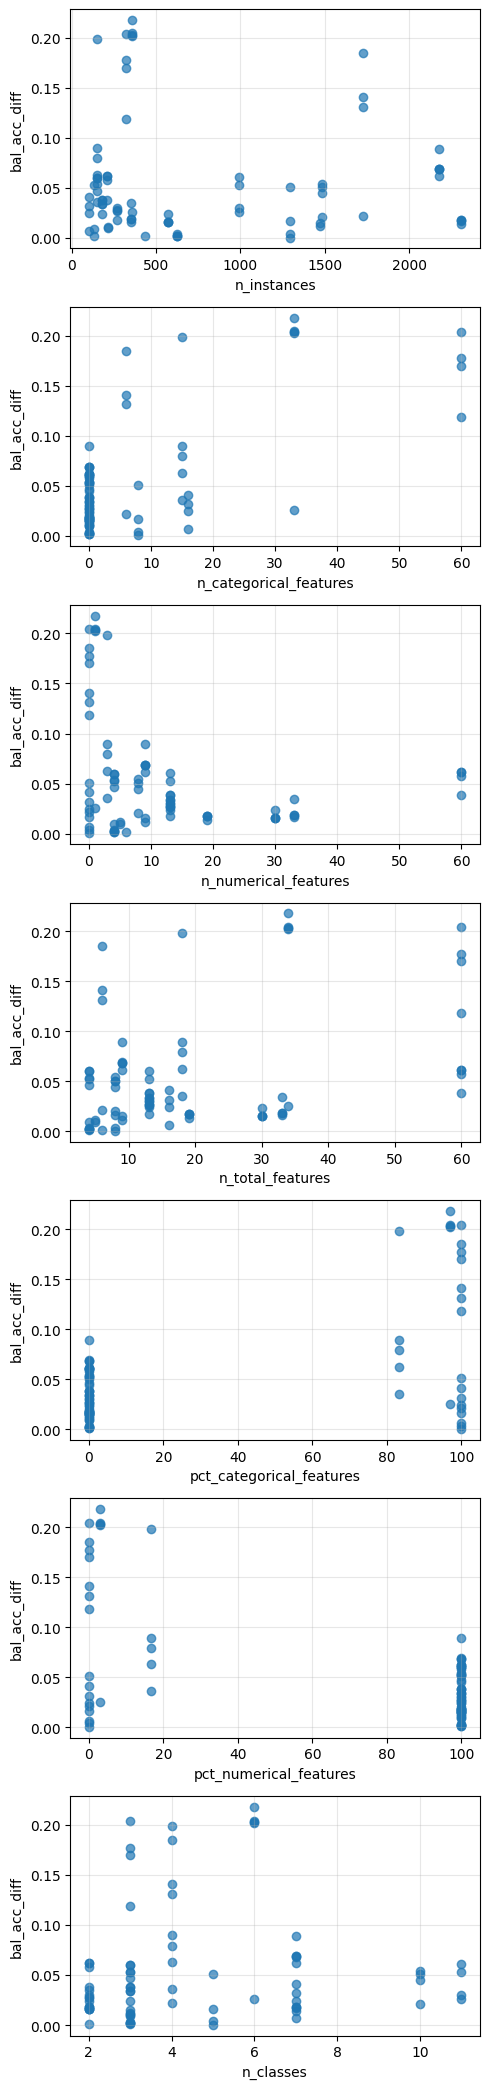

In [14]:
cols = [
    "n_instances",
    "n_categorical_features",
    "n_numerical_features",
    "n_total_features",
    "pct_categorical_features",
    "pct_numerical_features",
    "n_classes",
]

fig, axes = plt.subplots(len(cols), 1, figsize=(5, 3 * len(cols)), sharey=True)

for ax, col in zip(axes, cols):
    ax.scatter(aux_sum_res[col], aux_sum_res["bal_acc_diff"], alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel("bal_acc_diff")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Desempeño en empeoramiento

Computamos inicialmente el desempeño promedio en todos los datasets: 

In [74]:
aux_sum_res = sum_res[sum_res.bal_acc_diff<0].copy()

In [75]:
mean_better_performance = (
    aux_sum_res[
        ["method_base","bal_acc_diff","f1_macro_diff",#"prec_macro_diff",
         "rem_acc_removal_mean","rem_precision_removal_mean",
         "rem_recall_removal_mean","rem_removed_pct_mean"]
    ]
    .groupby("method_base")
    .mean()
    .reset_index()
    .rename(columns={
        "method_base": "Filtro",
        "bal_acc_diff": "bal_acc",
        "f1_macro_diff": "f1_macro",
        "prec_macro_diff": "prec_macro",
        "rem_acc_removal_mean": "acc",
        "rem_precision_removal_mean": "prec",
        "rem_recall_removal_mean": "recall",
        "rem_removed_pct_mean": "pct",
    })
)
mean_better_performance

,Filtro,bal_acc,f1_macro,acc,prec,recall,pct
0,ENN,-0.049049,-0.044657,0.662920,0.335285,0.834596,46.595171
1,ENNProb,-0.035646,-0.032168,0.700952,0.363618,0.840383,42.946732
2,ENNTh,-0.060605,-0.058022,0.677017,0.360080,0.888967,47.333712
3,MultiEdit,-0.143095,-0.170114,0.549204,0.288703,0.936411,60.808509
4,NCNEdit,-0.050367,-0.048271,0.675760,0.343185,0.828284,45.011486


Con a continuación un test de wilcoxon de doble dirección sobre las diferencias en bal_acc promedio:

In [76]:
rows = []

for mb, g in aux_sum_res.groupby("method_base"):
    vals = g["bal_acc_diff"].dropna()

    if len(vals) == 0 or np.allclose(vals, 0):
        pval = np.nan
    else:
        try:
            pval = wilcoxon(vals, alternative="two-sided").pvalue
        except ValueError:
            pval = np.nan

    rows.append({
        "Filtro": mb,
        "bal_acc": vals.mean(),
        "p_value": pval,
    })

tabla_w = pd.DataFrame(rows)
tabla_w

,Filtro,bal_acc,p_value
0,ENN,-0.049049,9.765625e-04
1,ENNProb,-0.035646,9.765625e-04
2,ENNTh,-0.060605,1.953125e-03
3,MultiEdit,-0.143095,1.192093e-07
4,NCNEdit,-0.050367,4.882812e-04


## Boxplot de los 3 casos anteriores


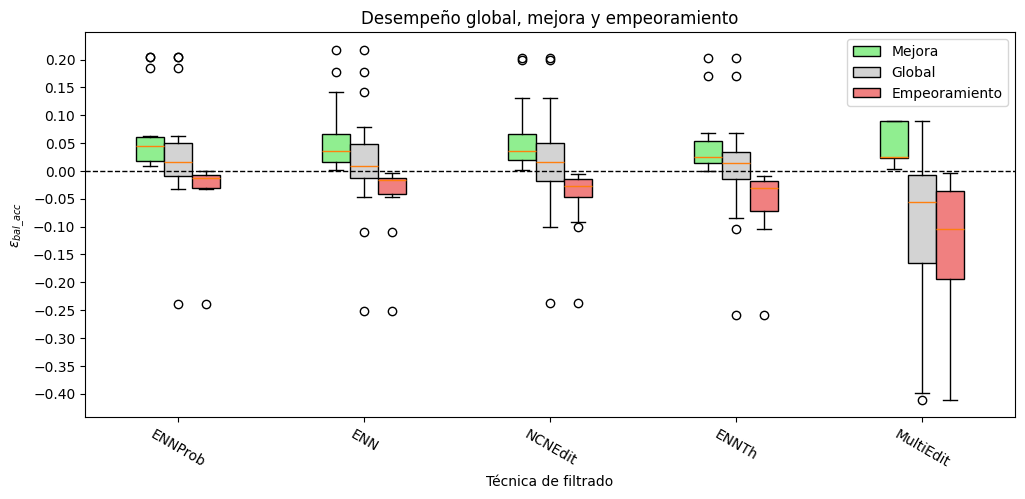

In [102]:
filtering_method_names = sorted(
    sum_res.method_base.unique().tolist(),
    key=lambda x: -mean_performance.loc[mean_performance.Filtro == x, "bal_acc"].iloc[0]
)

global_vals = [sum_res.loc[sum_res.method_base == mn, "bal_acc_diff"].dropna().values for mn in filtering_method_names]
better_vals = [sum_res.loc[(sum_res.method_base == mn) & (sum_res.bal_acc_diff > 0), "bal_acc_diff"].dropna().values for mn in filtering_method_names]
worse_vals = [sum_res.loc[(sum_res.method_base == mn) & (sum_res.bal_acc_diff < 0), "bal_acc_diff"].dropna().values for mn in filtering_method_names]

positions = np.arange(len(filtering_method_names)) * 4

fig, ax = plt.subplots(figsize=(12, 5))

bp2 = ax.boxplot(better_vals, positions=positions- 0.6, widths=0.6, patch_artist=True, manage_ticks=False)
bp1 = ax.boxplot(global_vals, positions=positions , widths=0.6, patch_artist=True, manage_ticks=False)
bp3 = ax.boxplot(worse_vals, positions=positions + 0.6, widths=0.6, patch_artist=True, manage_ticks=False)

for b in bp2["boxes"]:
    b.set_facecolor("lightgreen")
for b in bp1["boxes"]:
    b.set_facecolor("lightgray")
for b in bp3["boxes"]:
    b.set_facecolor("lightcoral")

ax.set_xticks(positions)
ax.set_xticklabels(filtering_method_names, rotation=-30)
ax.set_xlabel("Técnica de filtrado")
ax.set_ylabel(r"$\epsilon_{bal\_acc}$")
ax.set_title("Desempeño global, mejora y empeoramiento")
ax.legend([bp2["boxes"][0], bp1["boxes"][0],  bp3["boxes"][0]],
          ["Mejora", "Global",  "Empeoramiento"],
          loc="best")
plt.xlim(-2,18)
ax.hlines([0], -2,18, ls="--", color="black", lw=1)
plt.yticks(np.arange(-0.4,0.25,0.05))
plt.show()

# Resultados generales

In [6]:
res = {
    f"{method_type}_{noise_k}" : pickle.load(open(f"./all_results/all_results_{method_type}_cla_rand_1_{noise_k}.pkl", "rb"))
    for noise_k in  [25,50]
    for method_type in ["dists", "classif"]
}

In [ ]:
sums_res = {key:summarize_results(res[key]) for key in res.keys()}

In [11]:
wilcoxon_to_bal_acc_dif(sums_res["dists_50"])

,Filtro,bal_acc,p_value
0,ENN,0.020977,0.497314
1,ENNProb,0.013974,0.635498
2,ENNTh,-0.008359,0.735352
3,MENN,0.019195,0.497314
4,MultiEdit,0.009873,0.497314


# TABPFN

In [7]:
results = {
    noise_level:{
        filter_kind : pickle.load(open(f"./results/cla_rand/seed1/{noise_level}/{filter_kind}_cla_rand_1_{noise_level}.pkl", "rb"))
        for filter_kind in ["all_results_dists", "all_results_classif", "all_results_cncnos", "TABPFN"]
    }
    for noise_level in [5,25,50]
}
for noise_level in [5,25,50]:
    results[noise_level]["TABPFN"] = [{**e,**{"baseline_df":results[noise_level]["all_results_dists"][i]["baseline_df"]}} for i,e in enumerate(results[noise_level]["TABPFN"])]

/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/base.py:463: Inconsi

In [17]:
for noise_level in [5,25,50]:
    display(pd.concat([wilcoxon_to_bal_acc_dif(summarize_results(e)) for e in results[noise_level].values()], axis=0))

,Filtro,bal_acc,p_value
0,ENN,-0.011607,0.626346
1,ENNProb,-0.003824,0.597808
2,ENNTh,-0.015765,0.935399
3,MultiEdit,-0.141092,0.000004
4,NCNEdit,-0.007137,0.919297
0,CF,0.025045,0.000035
1,CVCF,0.000811,0.872577
2,CVCFTh,-0.000759,0.748966
3,Ensemble,0.015447,0.008143
4,EnsembleTh,NaN,NaN


,Filtro,bal_acc,p_value
0,ENN,0.016517,0.111991
1,ENNProb,0.025858,0.014538
2,ENNTh,0.008624,0.198076
3,MultiEdit,-0.110427,0.000110
4,NCNEdit,0.016360,0.177193
0,CF,0.045411,0.000018
1,CVCF,0.002197,0.720929
2,CVCFTh,0.000269,0.789472
3,Ensemble,0.038718,0.001053
4,EnsembleTh,0.039651,0.000952


,Filtro,bal_acc,p_value
0,CF,0.045411,0.000018
1,CVCF,0.002197,0.720929
2,CVCFTh,0.000269,0.789472
3,Ensemble,0.038718,0.001053
4,EnsembleTh,0.039651,0.000952
5,INFFC,0.031353,0.005383
6,INFFCTh,0.027412,0.012834
7,IPF,0.024876,0.000089
0,CF,0.045411,0.000018
1,CVCF,0.002197,0.720929


In [26]:
frames = []

for noise_level in [5, 25, 50]:
    for family_name, all_results in results[noise_level].items():
        df = wilcoxon_to_bal_acc_dif(summarize_results(all_results)).copy()
        df["noise_level"] = f"{noise_level}%"
        df["family"] = family_name
        frames.append(df)

long_df = pd.concat(frames, ignore_index=True)

# si quieres renombrar filtros
long_df["Filtro"] = long_df["Filtro"].replace({
    "CNCNOS": "CNC-NOS",
    "TABPFNClassificationFilter": "TABPFN",
})

display(long_df)

,Filtro,bal_acc,p_value,noise_level,family
0,ENN,-0.011607,0.626346,5%,all_results_dists
1,ENNProb,-0.003824,0.597808,5%,all_results_dists
2,ENNTh,-0.015765,0.935399,5%,all_results_dists
3,MultiEdit,-0.141092,0.000004,5%,all_results_dists
4,NCNEdit,-0.007137,0.919297,5%,all_results_dists
5,CF,0.025045,0.000035,5%,all_results_classif
6,CVCF,0.000811,0.872577,5%,all_results_classif
7,CVCFTh,-0.000759,0.748966,5%,all_results_classif
8,Ensemble,0.015447,0.008143,5%,all_results_classif
9,EnsembleTh,NaN,NaN,5%,all_results_classif


In [29]:
orden = ["5%", "25%", "50%"]

long_df["noise_level"] = pd.Categorical(
    long_df["noise_level"],
    categories=orden,
    ordered=True,
)

tabla = long_df.pivot_table(
    index=["Filtro"],
    columns="noise_level",
    values=["bal_acc", "p_value"],
    aggfunc="first",
)

tabla = tabla.reindex(columns=orden, level=1)
display(tabla)
print(tabla.to_latex(escape=False, multicolumn=True, multicolumn_format="c"))

bal_acc                       p_value                    
noise_level        5%       25%       50%        5%       25%       50%
Filtro                                                                 
CF           0.025045  0.045411  0.045411  0.000035  0.000018  0.000018
CNC-NOS     -0.021153  0.001701  0.027745  0.479096  0.779298  0.305226
CVCF         0.000811  0.002197  0.002197  0.872577  0.720929  0.720929
CVCFTh      -0.000759  0.000269  0.000269  0.748966  0.789472  0.789472
ENN         -0.011607  0.016517       NaN  0.626346  0.111991       NaN
ENNProb     -0.003824  0.025858       NaN  0.597808  0.014538       NaN
ENNTh       -0.015765  0.008624       NaN  0.935399  0.198076       NaN
Ensemble     0.015447  0.038718  0.038718  0.008143  0.001053  0.001053
EnsembleTh        NaN  0.039651  0.039651       NaN  0.000952  0.000952
INFFC        0.004655  0.031353  0.031353  0.205410  0.005383  0.005383
INFFCTh      0.008128  0.027412  0.027412  0.073244  0.012834  0.012834
IPF          0.012093  0.024876  0.024876  0.000315  0.000089  0.000089
MultiEdit   -0.141092 -0.110427       NaN  0.000004  0.000110       NaN
NCNEdit     -0.007137  0.016360       NaN  0.919297  0.177193       NaN
TABPFN       0.019868  0.043633 -0.007873  0.002188  0.004032  0.951526

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{3}{c}{bal_acc} & \multicolumn{3}{c}{p_value} \\
noise_level & 5% & 25% & 50% & 5% & 25% & 50% \\
Filtro &  &  &  &  &  &  \\
\midrule
CF & 0.025045 & 0.045411 & 0.045411 & 0.000035 & 0.000018 & 0.000018 \\
CNC-NOS & -0.021153 & 0.001701 & 0.027745 & 0.479096 & 0.779298 & 0.305226 \\
CVCF & 0.000811 & 0.002197 & 0.002197 & 0.872577 & 0.720929 & 0.720929 \\
CVCFTh & -0.000759 & 0.000269 & 0.000269 & 0.748966 & 0.789472 & 0.789472 \\
ENN & -0.011607 & 0.016517 & NaN & 0.626346 & 0.111991 & NaN \\
ENNProb & -0.003824 & 0.025858 & NaN & 0.597808 & 0.014538 & NaN \\
ENNTh & -0.015765 & 0.008624 & NaN & 0.935399 & 0.198076 & NaN \\
Ensemble & 0.015447 & 0.038718 & 0.038718 & 0.008143 & 0.001053 & 0.001053 \\
EnsembleTh & NaN & 0.039651 & 0.039651 & NaN & 0.000952 & 0.000952 \\
INFFC & 0.004655 & 0.031353 & 0.031353 & 0.205410 & 0.005383 & 0.005383 \\
INFFCTh & 0.008128 & 0.027412 & 0.027412 & 0.073244 & 0.012834 & 0.012834 \\
IPF & 0.012093 & 

# Prueba

In [27]:
all_results = pickle.load(open("./resultsEvaluation/5/seed01/knn/dists_res.pkl", "rb"))
print(f"Number of datasets: {len(all_results)}")

Number of datasets: 22


/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/base.py:463: Inconsi

In [28]:
summarize_results(all_results).keys()

Index(['dataset', 'n_instances', 'n_categorical_features',
       'n_numerical_features', 'n_total_features', 'pct_numerical_features',
       'pct_categorical_features', 'n_classes', 'method_base',
       'n_invalid_trainings', 'acc_diff', 'bal_acc_diff', 'f1_macro_diff',
       'prec_macro_diff', 'rec_macro_diff', 'removal_filter', 'rem_mcc_mean',
       'rem_recall_removal_mean', 'rem_precision_removal_mean',
       'rem_acc_removal_mean', 'rem_specificity_mean', 'rem_removed_pct_mean',
       'baseline_acc', 'baseline_bal_acc', 'baseline_f1_macro',
       'baseline_precision_macro', 'baseline_recall_macro', 'class_method',
       'class_acc_mean', 'class_f1_macro_mean', 'class_bal_acc_mean',
       'class_precision_macro_mean', 'class_recall_macro_mean',
       'rem_f1_removal_mean'],
      dtype='str')

In [31]:
summarize_results(all_results).filter(["dataset", "method_base", "baseline_acc", "baseline_elapsed_s", "class_acc_mean", "class_elapsed_s_mean", "rem_elapsed_s_mean"])

,dataset,method_base,baseline_acc,class_acc_mean
0,autos,CF,0.716734,0.584274
1,autos,ENN,0.716734,0.553226
2,autos,ENNTh,0.716734,0.565323
3,autos,NCNEdit,0.716734,0.571976
4,car,CF,0.705485,0.682900
...,...,...,...,...
83,wine,NCNEdit,0.899048,0.943810
84,yeast,CF,0.504059,0.547855
85,yeast,ENN,0.504059,0.548533
86,yeast,ENNTh,0.504059,0.562660
